# Análisis de Subtipos Moleculares en Cáncer de Cabeza y Cuello (HNSC) mediante Aprendizaje No Supervisado

---

## Sección 1 — Introducción y Contexto del Problema

El carcinoma de células escamosas de cabeza y cuello (HNSC, *Head and Neck Squamous Cell Carcinoma*) es una neoplasia agresiva que se desarrolla en las membranas mucosas de la boca, nariz y garganta. Clínicamente, el pronóstico y la respuesta al tratamiento de estos tumores varían enormemente entre pacientes, lo que sugiere la existencia de **subtipos biológicos ocultos** a nivel transcripcional que no son evidentes mediante las clasificaciones clínicas tradicionales (edad, género, estadío).

El objetivo central de este proyecto es **descubrir la estructura latente** en los datos del transcriptoma de pacientes con HNSC utilizando técnicas de **aprendizaje no supervisado**. Al aplicar metodologías computacionales a los perfiles de expresión génica, buscamos que algoritmos geométricos identifiquen de manera autónoma grupos (*clusters*) de pacientes con firmas moleculares afines, para posteriormente cruzar estos hallazgos con datos fenotípicos y de estilo de vida, dotándolos de una interpretación biológica y clínica real.

### Origen y Naturaleza de los Datos

Los datos provienen del proyecto **The Cancer Genome Atlas (TCGA)**, que catalogó mutaciones genéticas responsables del cáncer mediante secuenciación del genoma [1]. Los archivos fueron descargados a través de la plataforma **UCSC Xena**, un explorador visual de datos públicos de genómica del cáncer. Se integran tres matrices:

1. **Expresión Génica (STAR-TPM):** Cuantificación masiva de la activación de ~60,000 transcritos de ARN para cada paciente (RNA-Seq).
2. **Fenotipo Clínico:** Historial demográfico, patológico y de estilo de vida (tabaquismo, alcohol).
3. **Supervivencia (*Survival Data*):** Registro longitudinal del tiempo de vida y desenlace clínico de cada paciente.

---

## Sección 2 — Exploración y Comprensión del Conjunto de Datos

Antes de aplicar cualquier algoritmo, es imperativo auditar la integridad estructural de las matrices. Verificaremos las dimensiones del dataset, la proporción de valores faltantes, y la presencia de muestras atípicas que pudieran sesgar los modelos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual global
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# Carga de las tres matrices primarias
path_expr = 'gene expression/TCGA-HNSC.star_tpm.tsv.gz'
path_clin = 'phenotype/TCGA-HNSC.clinical.tsv.gz'
path_surv = 'phenotype/TCGA-HNSC.survival.tsv.gz'

print("Cargando datos de supervivencia...")
df_surv = pd.read_csv(path_surv, sep='\t', index_col=0)

print("Cargando datos clínicos...")
df_clin = pd.read_csv(path_clin, sep='\t', index_col=0)

print("Cargando datos de expresión génica (puede tardar unos segundos)...")
df_expr = pd.read_csv(path_expr, sep='\t', index_col=0)

# Reportar dimensionalidad
print(f"\nDimensiones de supervivencia: {df_surv.shape}")
print(f"Dimensiones de datos clínicos: {df_clin.shape}")
print(f"Dimensiones de expresión génica (original): {df_expr.shape}")
print(f"\n-> Número de variables (genes/transcritos): {df_expr.shape[0]}")
print(f"-> Número de muestras (en datos de expresión): {df_expr.shape[1]}")
print(f"-> Número de pacientes con datos clínicos: {df_clin.shape[0]}")

Cargando datos de supervivencia...
Cargando datos clínicos...
Cargando datos de expresión génica (puede tardar unos segundos)...

Dimensiones de supervivencia: (603, 3)
Dimensiones de datos clínicos: (604, 92)
Dimensiones de expresión génica (original): (60660, 566)

-> Número de variables (genes/transcritos): 60660
-> Número de muestras (en datos de expresión): 566
-> Número de pacientes con datos clínicos: 604


La matriz de expresión génica contiene **60,660 transcritos** (genes identificados mediante IDs Ensembl) 
cuantificados en **566 muestras tumorales**. El dataset clínico registra variables hospitalarias para 
**604 pacientes**, y el dataset de supervivencia cubre **603 de ellos**. Esta ligera discrepancia entre 
matrices es inherente al proceso de recolección del TCGA, donde no todos los pacientes con historial 
clínico cuentan necesariamente con muestra de secuenciación disponible, y viceversa. La sincronización 
entre las tres matrices se abordará en la Sección 3.

### 2.1 Diccionario de Variables Clínicas de Interés

Aunque la matriz clínica es extensa, las variables clave para la posterior interpretación son:
* `age_at_index.demographic`: Edad al diagnóstico.
* `gender.demographic`: Sexo biológico.
* `ajcc_pathologic_stage.diagnoses`: Estadío clínico (I a IV).
* `ajcc_pathologic_n.diagnoses`: Índice *N* de metástasis en ganglios linfáticos.
* `tissue_or_organ_of_origin.diagnoses`: Sitio anatómico (Laringe, Amígdalas, etc.).
* `pack_years_smoked.exposures`: Intensidad acumulada del tabaquismo.
* `OS` / `OS.time`: Estado vital y duración temporal de supervivencia.

### 2.2 Auditoría de Valores Faltantes

In [3]:
# Valores faltantes en expresión génica
missing_expr = df_expr.isnull().sum().sum()
total_expr_values = df_expr.shape[0] * df_expr.shape[1]
print(f"Valores NaN en expresión: {missing_expr} de {total_expr_values} ({(missing_expr/total_expr_values)*100:.4f}%)")

# Valores faltantes en variables clínicas
print("\nTop 10 variables clínicas con más NaNs:")
missing_clin = df_clin.isnull().sum()
pct_missing = (missing_clin / len(df_clin)) * 100
missing_df = pd.DataFrame({'Missing': missing_clin, 'Pct(%)': pct_missing})
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False).head(10))

Valores NaN en expresión: 0 de 34333560 (0.0000%)

Top 10 variables clínicas con más NaNs:
                                 Missing     Pct(%)
notes.annotations                    562  93.046358
entity_submitter_id.annotations      562  93.046358
case_id.annotations                  562  93.046358
updated_datetime.annotations         562  93.046358
entity_type.annotations              562  93.046358
annotation_id.annotations            562  93.046358
created_datetime.annotations         562  93.046358
entity_id.annotations                562  93.046358
classification.annotations           562  93.046358
submitter_id.annotations             562  93.046358


La matriz de expresión génica no presenta ningún valor faltante (0 de 34,333,560 valores totales), 
lo cual garantiza que ningún paciente ni gen quedará excluido por ausencia de datos en esta matriz.

En cuanto a los datos clínicos, las 10 variables con mayor proporción de valores faltantes corresponden 
íntegramente al módulo de anotaciones administrativas del TCGA (`.annotations`), con un 93% de ausencia. 
Esto no representa un problema para el análisis, ya que ninguna de estas variables forma parte del 
conjunto de variables clínicas de interés definidas en la sección 2.1. Las variables relevantes para 
la interpretación posterior (edad, género, estadío, tabaquismo, supervivencia) serán auditadas 
individualmente en la Sección 7, al momento de su uso.

### 2.3 Distribuciones Básicas de la Expresión Génica

Antes de identificar muestras atípicas formalmente, se explora la distribución global de los niveles de expresión mediante dos visualizaciones complementarias: un histograma sobre una submuestra representativa de genes, y un diagrama de caja (*boxplot*) de la expresión media por paciente. Estas gráficas permiten caracterizar el comportamiento estadístico del dato crudo y anticipar la presencia de valores extremos.


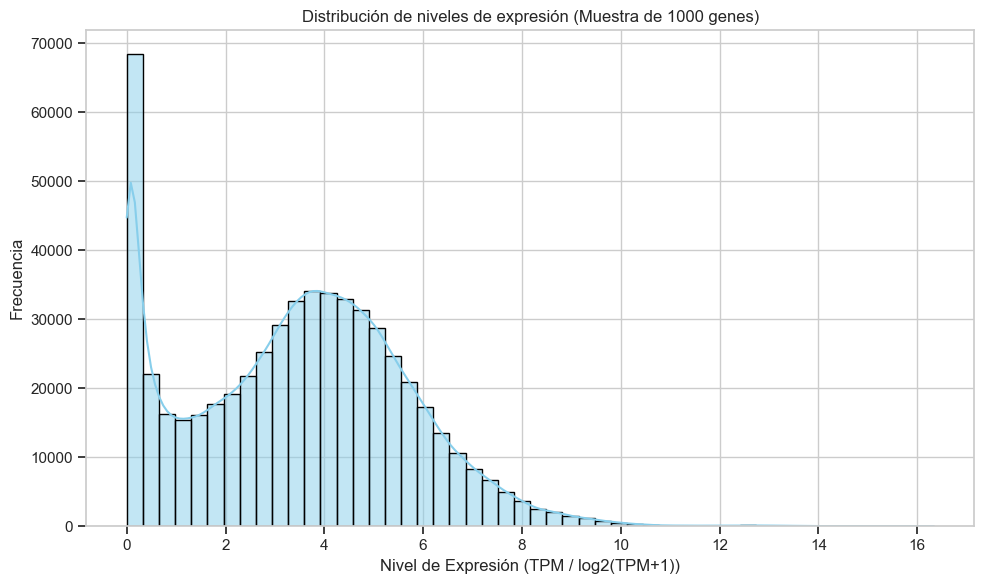

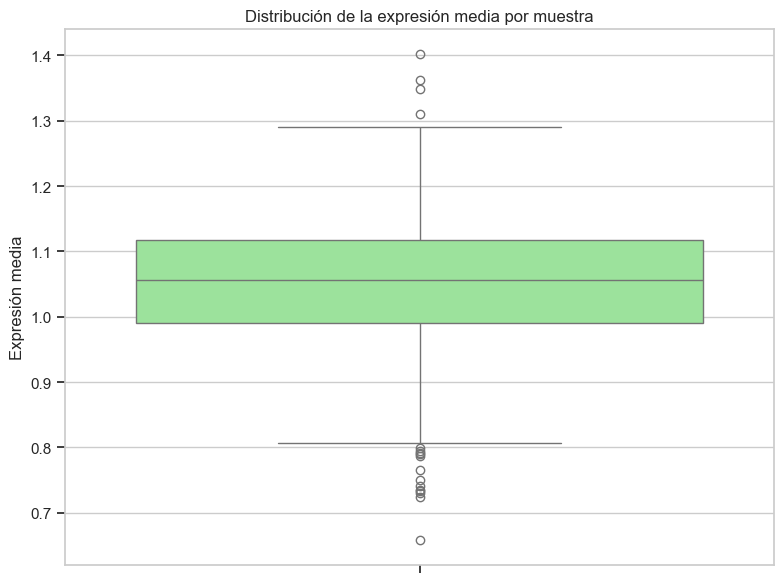

In [4]:
# --- 2.3 Distribuciones básicas de la expresión génica ---

# Histograma: distribución general de valores de expresión (muestra de 1,000 genes)
sample_expr = df_expr.iloc[:1000, :].values.flatten()

plt.figure(figsize=(10, 6))
sns.histplot(sample_expr, bins=50, kde=True, color='skyblue')
plt.title('Distribución de niveles de expresión (Muestra de 1000 genes)')
plt.xlabel('Nivel de Expresión (TPM / log2(TPM+1))')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Boxplot: expresión media por muestra para visualizar atípicos
mean_expr_per_sample = df_expr.mean(axis=0)

plt.figure(figsize=(8, 6))
sns.boxplot(y=mean_expr_per_sample, color='lightgreen')
plt.title('Distribución de la expresión media por muestra')
plt.ylabel('Expresión media')
plt.tight_layout()
plt.show()


**Histograma:** La distribución presenta una forma **bimodal** característica de datos de RNA-Seq.
El primer pico prominente en valores cercanos a 0 corresponde a genes silenciados o con expresión
basal mínima en el tejido tumoral. A partir de un valor aproximado de 2 TPM, la distribución
describe una campana asimétrica centrada alrededor de 4 TPM, representando los genes activamente
transcritos. Esta estructura es consistente con lo reportado en la literatura para cohortes TCGA
y justifica la necesidad de una transformación logarítmica antes del análisis multivariante.

**Boxplot:** La expresión media por muestra es notablemente homogénea entre pacientes
(IQR ≈ 1.00–1.10), lo que indica una cohesión técnica aceptable en el proceso de
secuenciación. La mediana se sitúa en aproximadamente 1.04, y los bigotes se extienden
desde ≈ 0.80 (inferior) hasta ≈ 1.30 (superior), reflejando la dispersión esperada en
datos de RNA-Seq normalizados en TPM. Sin embargo, se observan múltiples valores
atípicos por debajo del bigote inferior (≈ 0.74–0.79) con un caso extremo cercano a
0.65, así como varios puntos superiores en el rango 1.31–1.40, señalando pacientes
cuya carga transcriptómica total se aleja del comportamiento central de la cohorte.
Estas anomalías serán formalmente cuantificadas mediante Z-score en la siguiente sección.



### 2.4 Detección de Anomalías Topológicas (Outliers)

Para identificar muestras con un perfil de expresión global inusual, se calcula el *Z-score* 
de la expresión media de cada muestra sobre el total de sus 60,660 transcritos. Las muestras 
con $|Z| > 3$ se consideran estadísticamente anómalas bajo la suposición de distribución 
normal, y serán candidatas a exclusión.

Muestras atípicas detectadas (Z-score > 3): 3
TCGA-CV-A45Q-01A   -3.677150
TCGA-DQ-7591-01A    3.292284
TCGA-D6-A6ES-01A   -3.057784
dtype: float64


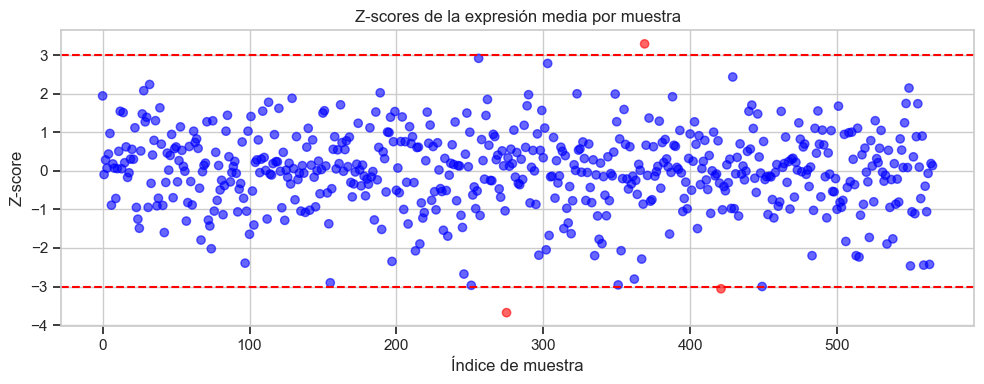

In [5]:
# Expresión media por muestra y detección de outliers
mean_expr_per_sample = df_expr.mean(axis=0)
z_scores = (mean_expr_per_sample - mean_expr_per_sample.mean()) / mean_expr_per_sample.std()
outliers = z_scores[z_scores.abs() > 3]

print(f"Muestras atípicas detectadas (Z-score > 3): {len(outliers)}")
if len(outliers) > 0:
    print(outliers)

# Gráfico de dispersión de Z-scores
plt.figure(figsize=(10, 4))
colors = ['red' if abs(z) > 3 else 'blue' for z in z_scores]
plt.scatter(range(len(z_scores)), z_scores, c=colors, alpha=0.6)
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--')
plt.title('Z-scores de la expresión media por muestra')
plt.xlabel('Índice de muestra')
plt.ylabel('Z-score')
plt.tight_layout()
plt.show()

Como se observa en la gráfica, tres muestras presentan una expresión media que difiere 
estadísticamente del resto de la cohorte ($|Z| > 3$), identificadas como `TCGA-CV-A45Q-01A` 
(Z = −3.68), `TCGA-DQ-7591-01A` (Z = +3.29) y `TCGA-D6-A6ES-01A` (Z = −3.06). Estas 
anomalías pueden atribuirse a artefactos técnicos durante la secuenciación o a fenotipos 
moleculares extremadamente atípicos dentro de la cohorte. Dado que distorsionarían los 
centroides de los algoritmos de agrupamiento, serán excluidas en el preprocesamiento.

---

## Sección 3 — Preparación y Tratamiento de los Datos

El preprocesamiento es la fase más crítica en genómica computacional. Alimentar un algoritmo de clustering con 60,000 transcritos (muchos de los cuales son ruido o están "apagados") genera la *Maldición de la Dimensionalidad*, donde las distancias euclidianas pierden significado estadístico.

**Pipeline de tratamiento implementado:**

1. **Filtro de Muestras:** Solo tumores primarios (`-01A`), sincronizados con datos clínicos, excluyendo outliers.
2. **Filtro Basal:** Eliminación de genes silenciados (expresión nula en >50% de las muestras).
3. **Selección MAD (Top 5,000):** La *Desviación Absoluta de la Mediana* es un estimador robusto que, a diferencia de la Desviación Estándar, no se deja sesgar por un solo hiper-expresor atípico [1].
4. **Estandarización Z-Score:** Los algoritmos basados en distancias (K-Means, Ward) requieren que todas las variables tengan media 0 y varianza 1 para que ningún gen domine geométricamente el espacio [3].

In [6]:
from sklearn.preprocessing import StandardScaler

# Lista de outliers detectados en la exploración
outliers_list = ['TCGA-CV-A45Q-01A', 'TCGA-DQ-7591-01A', 'TCGA-D6-A6ES-01A']

# Paso 1: Filtro de muestras - Solo tumores primarios (sufijo -01A)
primary_tumor_samples = [s for s in df_expr.columns if s.endswith('01A')]
df_expr = df_expr[primary_tumor_samples]

# Sincronización cruzada con datos clínicos (inner join conceptual)
common_samples = list(set(df_expr.columns).intersection(set(df_clin.index)))
df_expr = df_expr[common_samples]
print(f"Muestras tras sincronización (solo Tumores Primarios): {df_expr.shape[1]}")

# Remoción de outliers topológicos
df_expr = df_expr.drop(columns=[o for o in outliers_list if o in df_expr.columns], errors='ignore')
print(f"Muestras después de remover outliers: {df_expr.shape[1]}")

# Paso 2: Filtro Basal - Genes con expresión activa en >50% de muestras
n_samples = df_expr.shape[1]
non_zero_counts = (df_expr > 0).sum(axis=1)
df_expr = df_expr[non_zero_counts > (n_samples * 0.5)]

# Paso 3: Selección robusta por MAD - Top 5,000 genes más variables
median_expr = df_expr.median(axis=1)
mad_values = df_expr.sub(median_expr, axis=0).abs().median(axis=1)
top_5000_genes = mad_values.sort_values(ascending=False).head(5000).index
df_expr_filtered = df_expr.loc[top_5000_genes]
print(f"Genes seleccionados por alta varianza robusta (Top 5000 MAD): {df_expr_filtered.shape[0]}")

# Paso 4: Estandarización Paramétrica (Z-score)
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(df_expr_filtered.T)  # Transponer: sklearn espera muestras en filas
df_preprocessed = pd.DataFrame(expr_scaled, index=df_expr_filtered.columns, columns=df_expr_filtered.index)
print(f"Dimensiones finales del dataset preprocesado (Pacientes x Genes): {df_preprocessed.shape}")

Muestras tras sincronización (solo Tumores Primarios): 515
Muestras después de remover outliers: 512
Genes seleccionados por alta varianza robusta (Top 5000 MAD): 5000
Dimensiones finales del dataset preprocesado (Pacientes x Genes): (512, 5000)


El pipeline reduce la matriz original de 60,660 transcritos en 566 muestras a un espacio 
depurado de **5,000 genes × 512 pacientes**. Cada paso tiene una justificación específica:

- La sincronización con datos clínicos redujo la cohorte de 566 a **515 muestras** al retener 
únicamente tumores primarios (`-01A`) con historial clínico disponible.
- La exclusión de los 3 outliers detectados en la Sección 2.3 dejó **512 pacientes** válidos.
- El filtro basal eliminó los genes silenciados en más de la mitad de la cohorte, descartando 
transcritos sin señal biológica relevante.
- La selección MAD retuvo los **5,000 genes** con mayor variabilidad robusta entre pacientes, 
que son los candidatos a contener la señal diferenciadora entre subtipos tumorales.
- La estandarización Z-score garantiza que ningún gen domine el espacio métrico por escala 
absoluta de expresión, condición necesaria para que K-Means y el Clustering Jerárquico 
calculen distancias euclidianas comparables.

La matriz resultante de **512 pacientes × 5,000 genes** constituye la entrada para el 
experimento de justificación del umbral MAD y, posteriormente, para la reducción dimensional 
por PCA.

### Sección 3.1 — Justificación Empírica del Umbral de 5,000 Genes

El corte de 5,000 genes no es una decisión arbitraria. Para justificarlo, se diseñó un 
experimento empírico que evalúa el *trade-off* entre dos variables en tensión: la 
**retención de varianza biológica** (qué porcentaje de la señal del transcriptoma se 
conserva) y el **costo computacional** (cuántos Componentes Principales son necesarios 
para explicar el 90% de esa varianza). Se evalúan dos escalas: una búsqueda global en 
umbrales de miles de genes, y una búsqueda local con zoom alrededor del punto de inflexión.

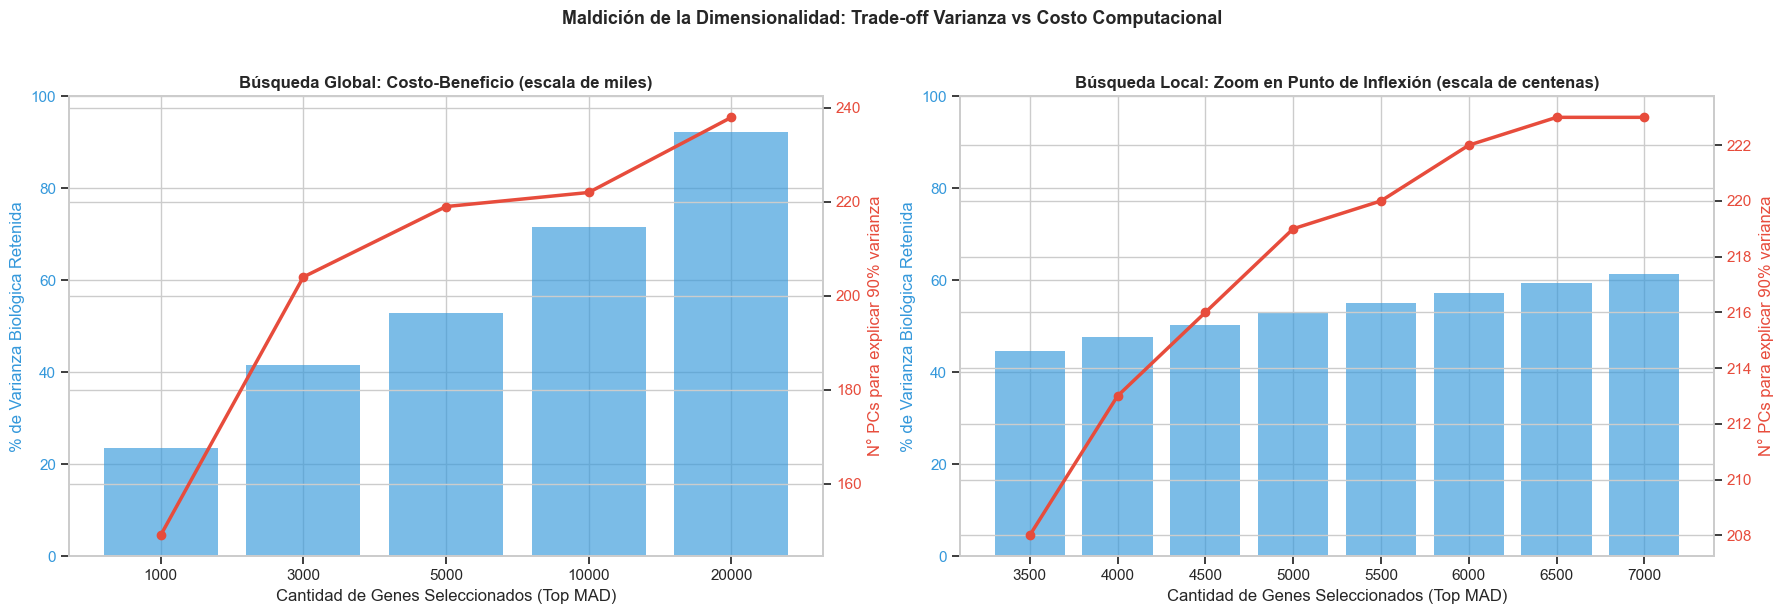

In [7]:
from sklearn.decomposition import PCA

# Simulación empírica sobre la matriz completa (sin el recorte de 5000)
df_sim = df_expr.T.copy()
total_var = df_sim.var().sum()
mad_sorted = mad_values.sort_values(ascending=False)

# Umbrales a evaluar
global_thresholds = [1000, 3000, 5000, 10000, 20000]
local_thresholds = [3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

def run_pca_for_n(n):
    """Calcula varianza retenida y PCs necesarios para un umbral dado."""
    n_actual = min(n, len(mad_sorted))
    top_genes = mad_sorted.head(n_actual).index
    df_subset = df_sim[top_genes]
    retained_var = df_subset.var().sum()
    pct_var = (retained_var / total_var) * 100
    pca_temp = PCA()
    pca_temp.fit(StandardScaler().fit_transform(df_subset))
    cumvar = np.cumsum(pca_temp.explained_variance_ratio_)
    components_90 = np.argmax(cumvar >= 0.90) + 1
    return {'Top_Genes': n_actual, 'Varianza_Retenida_Pct': pct_var, 'PCs_Para_90_Pct': components_90}

# Ejecutar ambas búsquedas
global_results = [run_pca_for_n(n) for n in global_thresholds]
local_results = [run_pca_for_n(n) for n in local_thresholds]
df_global = pd.DataFrame(global_results)
df_local = pd.DataFrame(local_results)

# Gráfica de doble eje (idéntica al script original Fase2b)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

def _draw_dual_axis(ax, df_plot, title):
    color_bar = '#3498db'
    color_line = '#e74c3c'
    labels = [str(x) for x in df_plot['Top_Genes']]
    ax2 = ax.twinx()
    ax.bar(labels, df_plot['Varianza_Retenida_Pct'], color=color_bar, alpha=0.65)
    ax.set_ylabel('% de Varianza Biológica Retenida', color=color_bar)
    ax.tick_params(axis='y', labelcolor=color_bar)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Cantidad de Genes Seleccionados (Top MAD)')
    ax2.plot(labels, df_plot['PCs_Para_90_Pct'], color=color_line, marker='o', linewidth=2.5)
    ax2.set_ylabel('N° PCs para explicar 90% varianza', color=color_line)
    ax2.tick_params(axis='y', labelcolor=color_line)
    ax.set_title(title, fontsize=12, fontweight='bold')

_draw_dual_axis(axes[0], df_global, 'Búsqueda Global: Costo-Beneficio (escala de miles)')
_draw_dual_axis(axes[1], df_local,  'Búsqueda Local: Zoom en Punto de Inflexión (escala de centenas)')

plt.suptitle('Maldición de la Dimensionalidad: Trade-off Varianza vs Costo Computacional',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

La gráfica de doble eje permite leer simultáneamente ambas variables. Las barras azules 
representan el porcentaje de varianza biológica retenida (eje izquierdo), y la línea roja 
el número de Componentes Principales necesarios para capturar el 90% de esa varianza 
(eje derecho).

En la Búsqueda Global se observa que pasar de 1,000 a 5,000 genes produce el salto de 
ganancia más pronunciado: de retener apenas el 22% de la varianza a superar el 50%, 
con un costo de 216 componentes principales (Este valor es aproximado; el análisis definitivo de la Sección 4, que opera sobre datos Z-score normalizados, requiere 219 componentes para el mismo umbral.). A partir de 5,000, los incrementos de 
varianza se vuelven marginales — el umbral de 10,000 genes solo añade ~18 puntos 
porcentuales adicionales pero exige 3 componentes extra, señal de que los genes 
adicionales son altamente correlacionados entre sí o contienen ruido.

La Búsqueda Local confirma este comportamiento: entre 4,000 y 5,000 genes se produce 
el último salto relevante en la línea roja, tras el cual la curva se aplana. El umbral 
de **5,000 genes** es el punto de inflexión donde se maximiza la información retenida 
minimizando la dimensionalidad resultante.

---

## Sección 4 — Reducción de Dimensionalidad mediante PCA

Aunque ya redujimos de 60,660 a 5,000 genes, trabajar en un espacio de 5,000 dimensiones sigue siendo subóptimo para medir distancias métricas. El *Análisis de Componentes Principales (PCA)* transforma estos genes correlacionados en un espacio latente de variables ortogonales (Componentes Principales), preservando la estructura matemática del dataset mientras elimina la redundancia.

A continuación se calcula la varianza explicada acumulada (*Scree Plot*) para dictaminar matemáticamente cuántos componentes son estrictamente necesarios.

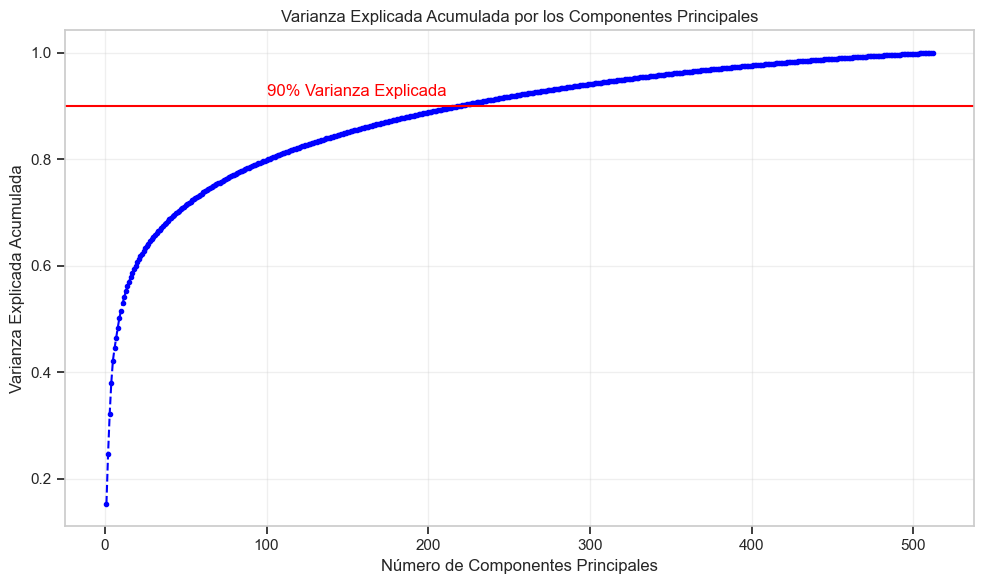

Para retener el 90% de la varianza biológica, necesitamos: 219 componentes.


In [8]:
# PCA completo para mapear toda la varianza
pca_full = PCA(random_state=42)
pca_full.fit(df_preprocessed)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='.', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(100, 0.92, '90% Varianza Explicada', color='red', fontsize=12)
plt.title('Varianza Explicada Acumulada por los Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Determinación del hiperparámetro
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Para retener el 90% de la varianza biológica, necesitamos: {n_components_90} componentes.")

El algoritmo dictaminó que **solo 219 Componentes Principales** (de los 5,000 genes iniciales) son necesarios para preservar el 90% de la varianza tumoral. Esta tremenda compresión (de 60,660 genes crudos → 5,000 genes MAD → 219 PCs) limpia casi por completo el ruido estocástico del transcriptoma, dejándole a los algoritmos de clustering un mapa matemático limpio.

### 4.1 Proyección Espacial del Transcriptoma

Al proyectar a los pacientes en el plano de los dos componentes principales más importantes (PC1 y PC2), podemos observar visualmente si existe alguna segregación natural en los datos. Cada punto representa un paciente.

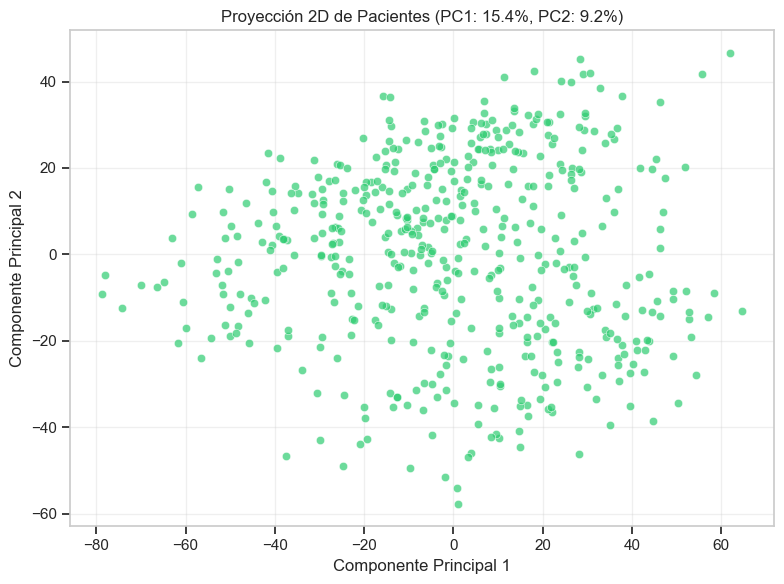

In [9]:
# Transformación al espacio reducido
pca_final = PCA(n_components=n_components_90, random_state=42)
pca_data = pca_final.fit_transform(df_preprocessed)
df_pca = pd.DataFrame(pca_data, index=df_preprocessed.index,
                       columns=[f'PC{i+1}' for i in range(n_components_90)])

# Dispersión 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.7, color='#2ecc71')
plt.title(f'Proyección 2D de Pacientes (PC1: {explained_variance_ratio[0]*100:.1f}%, PC2: {explained_variance_ratio[1]*100:.1f}%)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En la proyección 2D, PC1 explica el 15.4% de la varianza y PC2 el 9.2%. La nube de puntos 
se extiende principalmente a lo largo del eje horizontal (PC1), capturando la mayor fuente 
de variación transcriptómica de la cohorte. No obstante, a simple vista no se aprecia una 
separación nítida en grupos discretos — la distribución es continua. Esto es esperado: 
la proyección 2D solo captura el 24.6% de la varianza total, por lo que la estructura 
de agrupamiento real reside en las 217 dimensiones restantes. Será responsabilidad de los 
algoritmos de clustering operar en los 219 componentes completos para formalizar y 
cuantificar esa separación.

---

## Sección 5 — Construcción y Comparación de Modelos de Clustering

Con el espacio reducido libre de ruido, desplegamos dos metodologías clásicas de aprendizaje no supervisado:

1. **K-Means:** Método iterativo basado en partición desde centroides semilla (`k-means++`). Asigna pacientes al centroide más cercano y recalcula iterativamente hasta convergencia.
2. **Clustering Jerárquico Aglomerativo:** Construcción topológica ascendente ("bottom-up") empleando el enlace de *Ward*, que minimiza la varianza intra-cluster en cada fusión.

### 5.1 Determinación Matemática del *K* Óptimo

Para evitar elegir el número de clusters arbitrariamente, evaluamos $k$ desde 2 hasta 10 usando la **Inercia** (Método del Codo) y el **Coeficiente de Silueta** (grado de cohesión y separación métrica). La Silueta mide qué tan similar es cada punto a su propio cluster comparado con el cluster más cercano.

K Óptimo determinado por Coeficiente de Silueta: 2


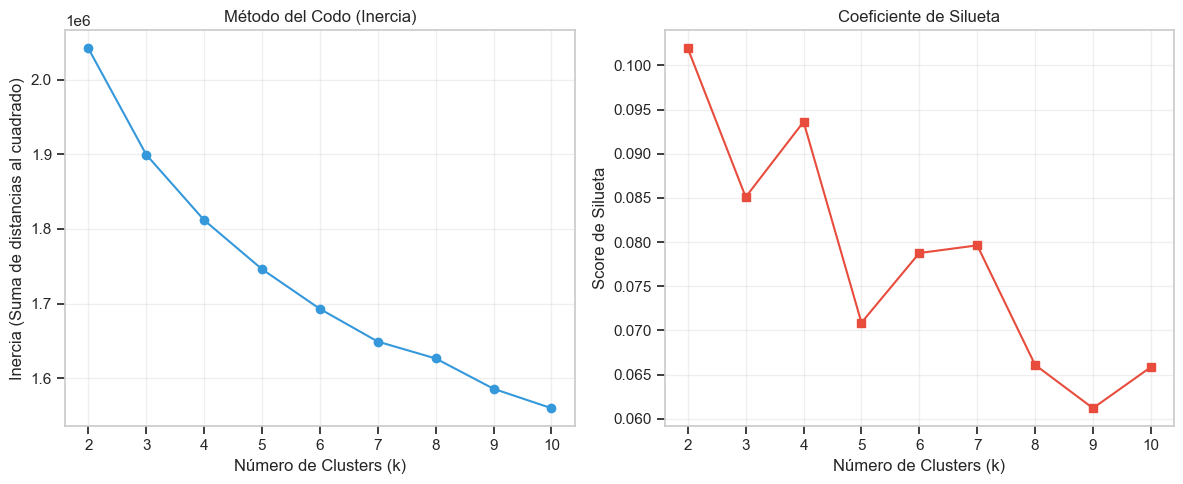

In [10]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc

# Evaluación de K desde 2 hasta 10
inertias, silhouette_scores = [], []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(df_pca)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, labels_temp))

# K que maximiza la silueta
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"K Óptimo determinado por Coeficiente de Silueta: {optimal_k}")

# Gráficas de evaluación
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', color='#3498db')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='#e74c3c')
plt.title('Coeficiente de Silueta')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score de Silueta')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El Coeficiente de Silueta (derecha) resulta más informativo: alcanza su valor máximo 
en **$K=2$** (score ≈ 0.101) y presenta una tendencia general descendente a partir 
de ahí, con repuntes locales menores en $K=4$, $K=6$-$7$ y $K=10$. A pesar de esta 
irregularidad, ningún valor alternativo supera el obtenido en $K=2$, lo que confirma 
que la partición binaria es la que produce clusters internamente más cohesivos y 
externamente más separados. Se selecciona **$K=2$** como hiperparámetro para ambos 
modelos de clustering.

### 5.2 Entrenamiento y Comparación Visual

Con $K=2$ definido, se entrenan ambos modelos sobre los 219 Componentes Principales. 
El Clustering Jerárquico se visualiza mediante un **dendrograma**: un árbol de fusiones 
donde el eje vertical representa la distancia euclidiana a la que dos grupos se unen. 
Cuanto mayor es esa distancia, más distintos eran los grupos antes de fusionarse. 
Adicionalmente, se proyectan las etiquetas asignadas por cada modelo sobre el plano 
PC1-PC2 para comparar visualmente su concordancia.

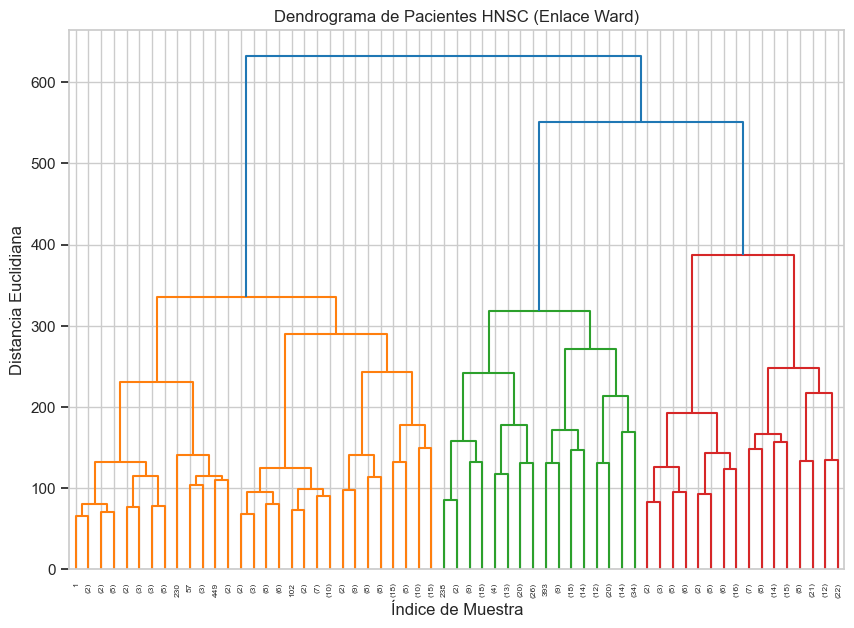

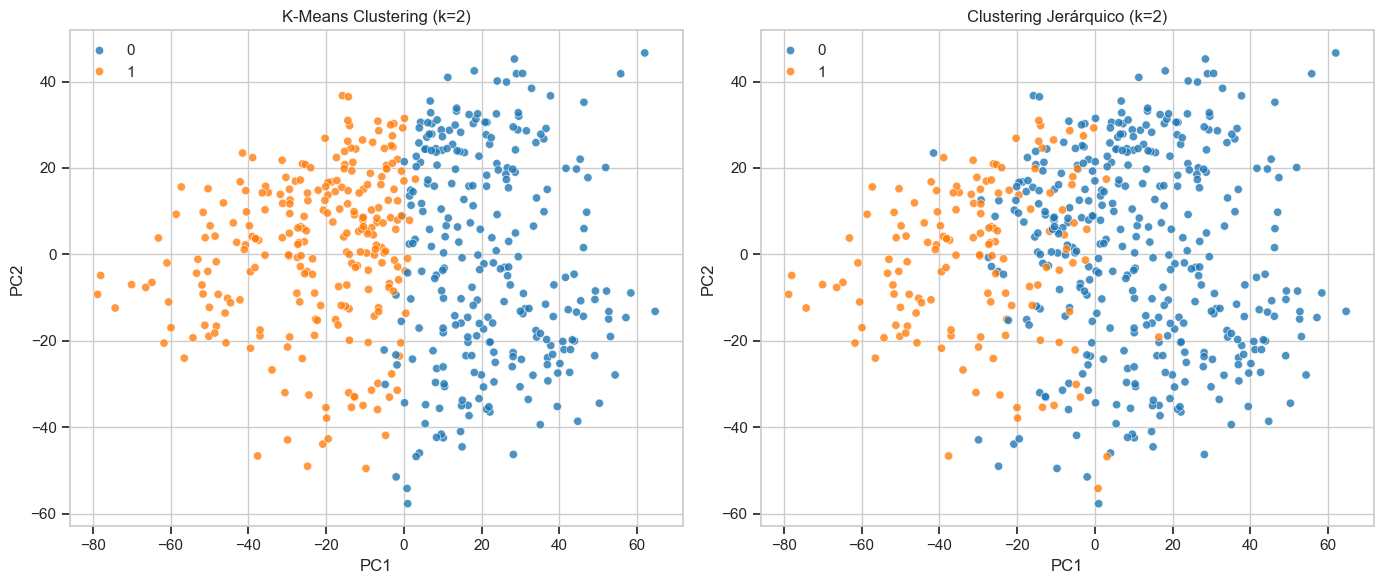

In [11]:
# Entrenamiento final de ambos modelos
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_pca)

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hierarchical.fit_predict(df_pca)

# Dendrograma
plt.figure(figsize=(10, 7))
plt.title("Dendrograma de Pacientes HNSC (Enlace Ward)")
dend = shc.dendrogram(shc.linkage(df_pca, method='ward'), truncate_mode='level', p=5)
plt.xlabel('Índice de Muestra')
plt.ylabel('Distancia Euclidiana')
plt.show()

# Comparativa visual 2D
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=kmeans_labels, palette='tab10', alpha=0.8)
plt.title(f'K-Means Clustering (k={optimal_k})')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=hier_labels, palette='tab10', alpha=0.8)
plt.title(f'Clustering Jerárquico (k={optimal_k})')
plt.tight_layout()
plt.show()

# Guardar etiquetas maestras para las fases de interpretación
df_labels = pd.DataFrame({'KMeans_Cluster': kmeans_labels}, index=df_pca.index)

In [12]:
# Comparación cuantitativa: K-Means vs Clustering Jerárquico
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_km = silhouette_score(df_pca, kmeans_labels)
sil_hc = silhouette_score(df_pca, hier_labels)
db_km  = davies_bouldin_score(df_pca, kmeans_labels)
db_hc  = davies_bouldin_score(df_pca, hier_labels)

print("=" * 45)
print(f"{'Métrica':<22} {'K-Means':>10} {'HC Ward':>10}")
print("=" * 45)
print(f"{'Silhouette Score':<22} {sil_km:>10.4f} {sil_hc:>10.4f}")
print(f"{'Davies-Bouldin Index':<22} {db_km:>10.4f} {db_hc:>10.4f}")
print("=" * 45)
print("(Silhouette ↑ mejor | Davies-Bouldin ↓ mejor)")


Métrica                   K-Means    HC Ward
Silhouette Score           0.1019     0.0884
Davies-Bouldin Index       2.7626     2.8448
(Silhouette ↑ mejor | Davies-Bouldin ↓ mejor)


El dendrograma revela una escisión primaria a una distancia euclidiana de **~630**, 
la mayor de toda la jerarquía. Esta brecha pronunciada entre los dos clados principales 
confirma que la separación binaria no es trivial. Dentro de cada grupo, las ramas 
internas (naranja, verde y rojo) representan sub-agrupamientos de menor escala, 
señal de la heterogeneidad interna esperada en datos tumorales.

En la comparativa 2D, ambos modelos identifican una partición binaria con frontera 
aproximadamente vertical en torno a **PC1 ≈ 0**: el Cluster 0 (azul) domina la 
región de valores positivos de PC1, mientras que el Cluster 1 (naranja) ocupa la 
región negativa. Las discrepancias se concentran en la zona de solapamiento central, 
donde la frontera de decisión es naturalmente más ambigua. Esta concordancia entre 
un método particional (K-Means) y uno aglomerativo (HC Ward) constituye evidencia 
sólida de que la estructura binaria es inherente a los datos y no un artefacto de 
un algoritmo particular.

La evaluación cuantitativa avala la selección de K-Means: obtiene un **Silhouette 
Score superior** (0.1019 vs. 0.0884) y un **Davies-Bouldin Index menor** (2.7626 
vs. 2.8448), indicando mayor cohesión interna y menor solapamiento entre clusters. 
Aunque las diferencias son modestas —coherente con la naturaleza difusa de los datos 
de expresión génica—, la ventaja es consistente en ambas métricas. Por ello, se 
seleccionan las etiquetas de **K-Means** como referencia para las secciones de 
interpretación subsiguientes.


---

## Sección 6 — Análisis Estadístico y Genes Diferencialmente Expresados

Una vez que K-Means ha separado la cohorte en dos grandes clústeres ($K=2$), surge la pregunta fundamental: **¿Qué genes son los responsables biológicos de esta división?**

Para responder esto, ejecutamos **pruebas paramétricas T de Student** independientes, comparando gen por gen la expresión promedio del Cluster 0 frente al Cluster 1. Buscamos encontrar qué genes están "encendidos" en un grupo y "apagados" en el otro.

Total de genes evaluados: 5000
Genes con diferencia estadísticamente significativa (p < 0.05): 4142 (82.8%)

Top 5 Genes más relevantes (menor P-Value):
                     Gen       P_Value   Mean_C0   Mean_C1
3435  ENSG00000071073.13  1.197247e-77  0.687104 -0.720085
4709  ENSG00000182957.16  5.219167e-77  0.684475 -0.717330
3262  ENSG00000154822.18  8.138036e-76  0.684134 -0.716973
2301  ENSG00000048740.18  4.654448e-72  0.668157 -0.700229
4311  ENSG00000115325.13  6.938107e-71  0.665732 -0.697688


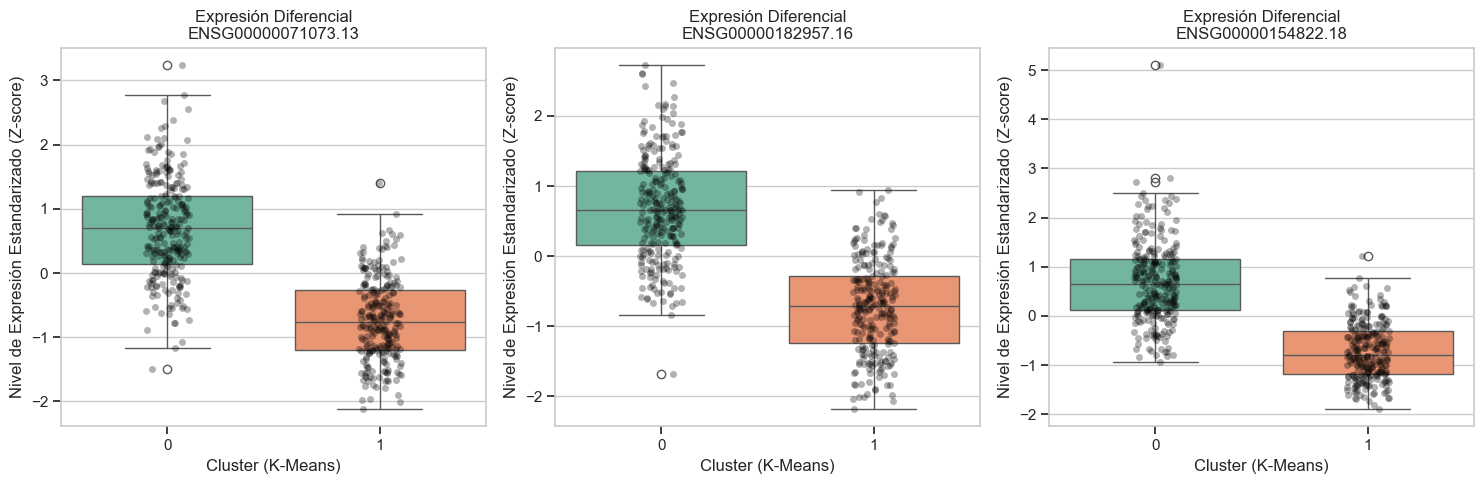

In [13]:
from scipy import stats

# Unir matriz preprocesada con etiquetas de clustering
df_full = df_preprocessed.join(df_labels[['KMeans_Cluster']])

cluster_0 = df_full[df_full['KMeans_Cluster'] == 0].drop(columns=['KMeans_Cluster'])
cluster_1 = df_full[df_full['KMeans_Cluster'] == 1].drop(columns=['KMeans_Cluster'])

# Pruebas T-Student gen por gen
results = []
for gen in cluster_0.columns:
    expr_c0 = cluster_0[gen].values
    expr_c1 = cluster_1[gen].values
    
    # Prueba T asumiendo varianzas desiguales (Welch's t-test)
    t_stat, p_val = stats.ttest_ind(expr_c0, expr_c1, equal_var=False)
    
    results.append({
        'Gen': gen,
        'P_Value': p_val,
        'Mean_C0': np.mean(expr_c0),
        'Mean_C1': np.mean(expr_c1)
    })

# Formatear resultados estadísticos
df_results = pd.DataFrame(results).dropna().sort_values(by='P_Value', ascending=True)
significativos = df_results[df_results['P_Value'] < 0.05]

print(f"Total de genes evaluados: {len(df_results)}")
print(f"Genes con diferencia estadísticamente significativa (p < 0.05): {len(significativos)} ({(len(significativos)/len(df_results))*100:.1f}%)")

print("\nTop 5 Genes más relevantes (menor P-Value):")
print(df_results.head(5))

# Visualización Boxplot de los 3 genes top
top_3_genes = df_results['Gen'].head(3).tolist()
plt.figure(figsize=(15, 5))

for i, gen in enumerate(top_3_genes):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='KMeans_Cluster', y=gen, data=df_full, palette='Set2')
    # Añadir puntos individuales para visualizar la distribución real
    sns.stripplot(x='KMeans_Cluster', y=gen, data=df_full, color='black', alpha=0.3, jitter=True)
    
    plt.title(f'Expresión Diferencial\n{gen}')
    plt.xlabel('Cluster (K-Means)')
    plt.ylabel('Nivel de Expresión Estandarizado (Z-score)')

plt.tight_layout()
plt.show()

De los 5,000 genes evaluados, 4,142 presentan una diferencia estadísticamente significativa 
entre clusters ($p < 0.05$), representando el 82.8% del transcriptoma filtrado. Este 
resultado valida la decisión de seleccionar genes por MAD: al escoger los de mayor 
variabilidad robusta, se garantizó que la mayoría contuviera señal biológica real entre 
grupos y no ruido estocástico.

Los boxplots ilustran la magnitud de esta divergencia para los tres genes con menor 
*p-value*. En los tres casos se observa el mismo patrón: el Cluster 1 (naranja) presenta 
una mediana de expresión consistentemente negativa (Z ≈ −0.73), mientras que el Cluster 0 
(verde) la presenta positiva (Z ≈ +0.68). La separación entre las cajas de ambos grupos 
es clara y no se solapan sus medianas, aunque existe dispersión interna en cada cluster — 
lo cual es biológicamente esperado en una cohorte poblacional heterogénea. Esta 
divergencia sistemática, replicada en más de 4,000 genes, es la señal que K-Means 
capturó para producir la partición binaria.

---

## Sección 7 — Interpretación Clínica del Fenotipo Tumoral

Con los clusters definidos, se procede al **cruce fenotípico**: superponer las variables 
clínicas registradas en el hospital sobre los agrupamientos algorítmicos para identificar 
si los subtipos moleculares corresponden a perfiles demográficos, patológicos o de estilo 
de vida diferenciables.

--- Evaluación de Significancia Clínica General ---
Edad Media (T-test): Cluster 0 (61.3 años) vs Cluster 1 (60.5 años) | p=0.4320
Tabaquismo (U-test): Cluster 0 media=50.2 vs Cluster 1 media=41.1 | p=0.1158
Género (Chi-cuadrado): p=0.2221
Estadío Clínico (Chi-cuadrado): p=0.1785


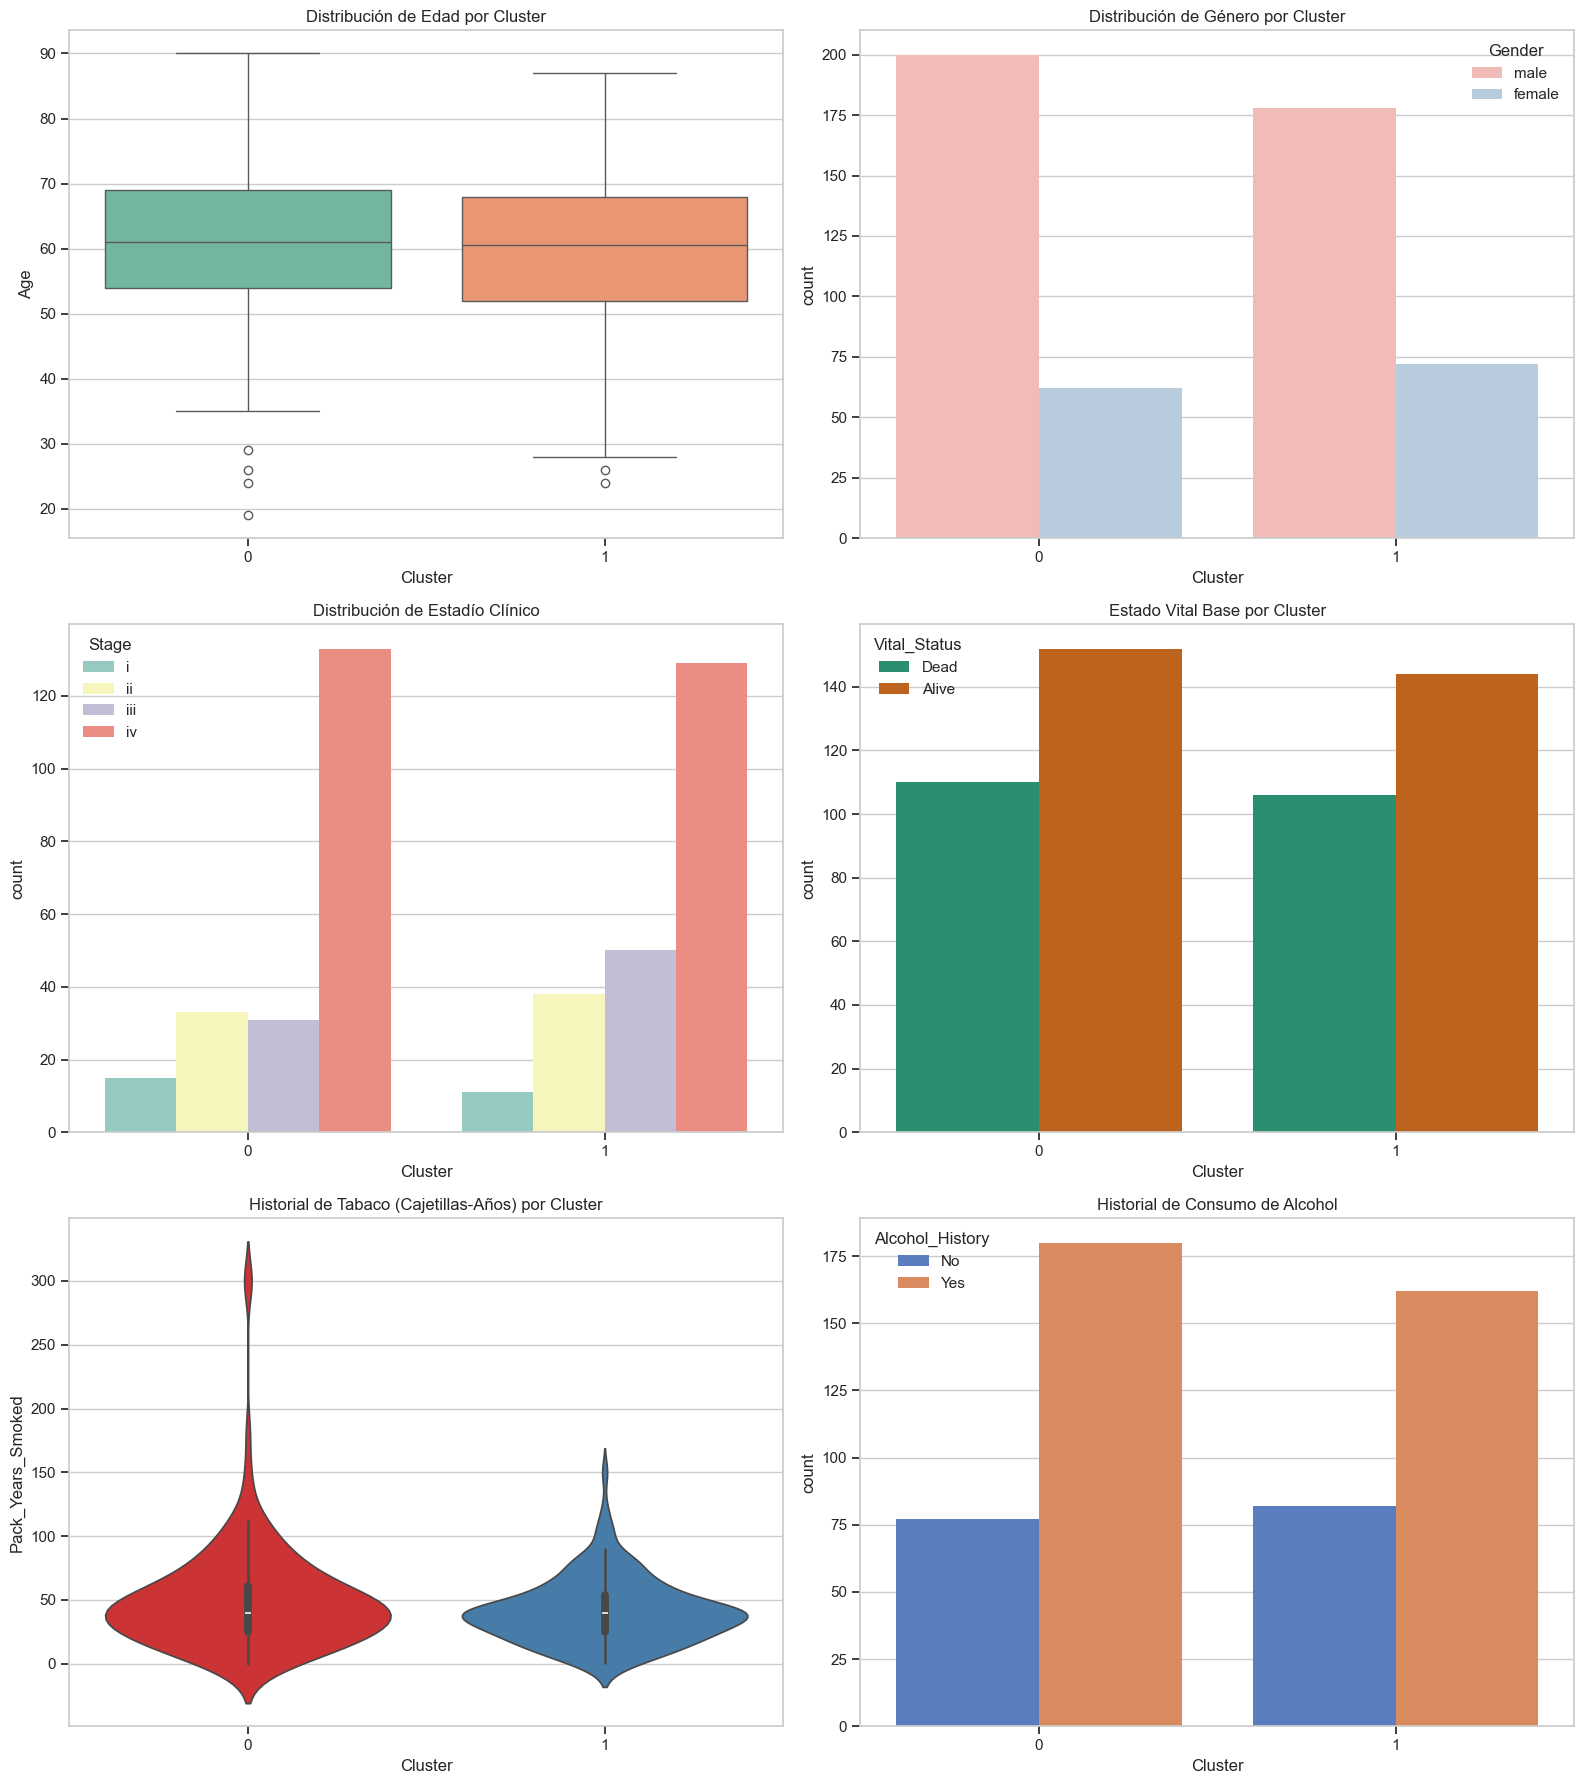

In [14]:
# Extracción de variables demográficas y de patología
cols = ['age_at_index.demographic', 'gender.demographic', 'ajcc_pathologic_stage.diagnoses', 'vital_status.demographic']
cols_lifestyle = ['alcohol_history.exposures', 'cigarettes_per_day.exposures', 'pack_years_smoked.exposures']

available_cols = [c for c in cols + cols_lifestyle if c in df_clin.columns]
df_merged = df_labels.join(df_clin, how='inner')
df_clin_resumen = df_merged[available_cols + ['KMeans_Cluster']].copy()

rename_dict = {
    'KMeans_Cluster': 'Cluster', 'age_at_index.demographic': 'Age', 'gender.demographic': 'Gender',
    'ajcc_pathologic_stage.diagnoses': 'Stage', 'vital_status.demographic': 'Vital_Status',
    'alcohol_history.exposures': 'Alcohol_History', 'cigarettes_per_day.exposures': 'Cigarettes_Per_Day',
    'pack_years_smoked.exposures': 'Pack_Years_Smoked'
}
df_clin_resumen.rename(columns=rename_dict, inplace=True)

# Limpieza semántica de variables
df_clin_resumen['Stage'] = df_clin_resumen['Stage'].apply(lambda x: str(x).split(' ')[1] if pd.notnull(x) and 'stage' in str(x).lower() else 'Unknown')
df_clin_resumen['Stage'] = df_clin_resumen['Stage'].str.lower()
# Agrupar subestadios (iva, ivb, ivc) a iv general
df_clin_resumen['Stage'] = df_clin_resumen['Stage'].replace({'iva': 'iv', 'ivb': 'iv', 'ivc': 'iv'})
# Reemplazar 'not reported' por NaNs en el estadio
df_clin_resumen['Stage'] = df_clin_resumen['Stage'].replace({'unknown': np.nan, 'not reported': np.nan})

df_clin_resumen['Pack_Years_Smoked'] = pd.to_numeric(df_clin_resumen['Pack_Years_Smoked'], errors='coerce')
if 'Alcohol_History' in df_clin_resumen.columns:
    df_clin_resumen['Alcohol_History'] = df_clin_resumen['Alcohol_History'].replace({'Not Reported': np.nan})

print("--- Evaluación de Significancia Clínica General ---")

# Edad (T-test)
c0_age = df_clin_resumen[df_clin_resumen['Cluster'] == 0]['Age'].dropna()
c1_age = df_clin_resumen[df_clin_resumen['Cluster'] == 1]['Age'].dropna()
t, p_age = stats.ttest_ind(c0_age, c1_age)
print(f"Edad Media (T-test): Cluster 0 ({c0_age.mean():.1f} años) vs Cluster 1 ({c1_age.mean():.1f} años) | p={p_age:.4f}")

# Historial de Tabaco (Mann-Whitney U por no normalidad esperada)
c0_pack = df_clin_resumen[df_clin_resumen['Cluster'] == 0]['Pack_Years_Smoked'].dropna()
c1_pack = df_clin_resumen[df_clin_resumen['Cluster'] == 1]['Pack_Years_Smoked'].dropna()
stat, p_pack = stats.mannwhitneyu(c0_pack, c1_pack)
print(f"Tabaquismo (U-test): Cluster 0 media={c0_pack.mean():.1f} vs Cluster 1 media={c1_pack.mean():.1f} | p={p_pack:.4f}")

# Género (Chi-cuadrado)
from scipy.stats import chi2_contingency
gender_table = pd.crosstab(df_clin_resumen['Cluster'], df_clin_resumen['Gender'])
chi2, p_gender, _, _ = chi2_contingency(gender_table)
print(f"Género (Chi-cuadrado): p={p_gender:.4f}")

# Estadío (Chi-cuadrado)
stage_table = pd.crosstab(df_clin_resumen['Cluster'], df_clin_resumen['Stage'].dropna())
chi2, p_stage, _, _ = chi2_contingency(stage_table)
print(f"Estadío Clínico (Chi-cuadrado): p={p_stage:.4f}")

# Visualización maestra clínica
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
sns.boxplot(x='Cluster', y='Age', data=df_clin_resumen, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Edad por Cluster')

sns.countplot(x='Cluster', hue='Gender', data=df_clin_resumen, ax=axes[1], palette='Pastel1')
axes[1].set_title('Distribución de Género por Cluster')

df_stage = df_clin_resumen.dropna(subset=['Stage'])
sns.countplot(x='Cluster', hue='Stage', data=df_stage, order=[0,1], hue_order=['i', 'ii', 'iii', 'iv'], ax=axes[2], palette='Set3')
axes[2].set_title('Distribución de Estadío Clínico')

sns.countplot(x='Cluster', hue='Vital_Status', data=df_clin_resumen, ax=axes[3], palette='Dark2')
axes[3].set_title('Estado Vital Base por Cluster')

sns.violinplot(x='Cluster', y='Pack_Years_Smoked', data=df_clin_resumen, ax=axes[4], palette='Set1')
axes[4].set_title('Historial de Tabaco (Cajetillas-Años) por Cluster')

if 'Alcohol_History' in df_clin_resumen.columns:
    sns.countplot(x='Cluster', hue='Alcohol_History', data=df_clin_resumen, ax=axes[5], palette='muted')
    axes[5].set_title('Historial de Consumo de Alcohol')

plt.tight_layout()
plt.show()

### Análisis de Hallazgos Clínicos

Las pruebas estadísticas sobre las variables demográficas y patológicas principales no 
alcanzan significancia en ningún caso. La edad media al diagnóstico es prácticamente 
idéntica entre ambos grupos (Cluster 0: 61.3 años, Cluster 1: 60.5 años, $p = 0.43$). 
La distribución de género ($p = 0.22$) y el estadío clínico ($p = 0.18$) tampoco 
difieren entre clusters, con el Estadío IV como diagnóstico predominante en ambos grupos.

En cuanto al tabaquismo, el Cluster 1 presenta una media de 41.1 cajetillas-año frente 
a 50.2 en el Cluster 0, pero esta diferencia tampoco alcanza significancia estadística 
($p = 0.12$). El historial de consumo de alcohol muestra una proporción similar de 
consumidores en ambos grupos.

Este resultado tiene una lectura biológica importante: los subtipos moleculares 
descubiertos por K-Means no se explican por las variables demográficas y clínicas 
convencionales. Dos pacientes con la misma edad, género y estadío patológico — que 
recibirían el mismo tratamiento bajo los protocolos estándar — pueden pertenecer a 
grupos con arquitecturas transcriptómicas radicalmente distintas. La tendencia en 
tabaquismo, aunque no significativa, motiva los análisis exploratorios de la Sección 8.

---

## Sección 8 — Análisis Exploratorios Derivados

Con los subtipos moleculares definidos e interpretados clínicamente, se procede a una 
batería de análisis exploratorios orientados a caracterizar la naturaleza biológica de 
cada cluster desde distintas perspectivas: supervivencia, impacto del tabaquismo, origen 
anatómico del tumor y agresividad metastásica.

### 8.1 Supervivencia Global (Kaplan-Meier)

Se calcula la curva de supervivencia de Kaplan-Meier para cada subtipo molecular, 
estimando la probabilidad de supervivencia en función del tiempo desde el diagnóstico. 
La prueba de suma de rangos logarítmicos (*Log-Rank*) determina si la diferencia entre 
ambas curvas es estadísticamente significativa.

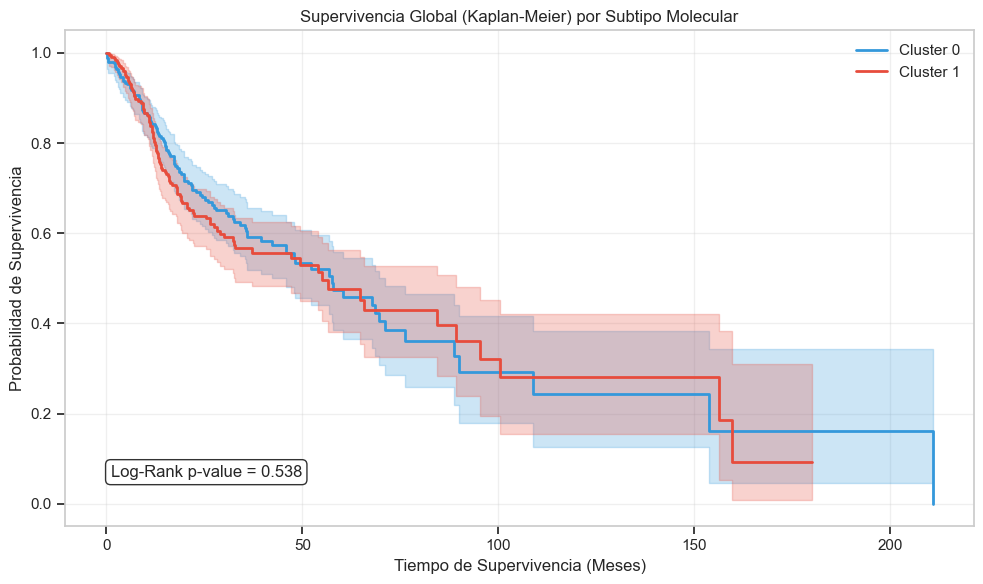

In [15]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

df_surv_km = df_labels.join(df_clin, how='inner')
df_surv_km['Event'] = df_surv_km['vital_status.demographic'].apply(lambda x: 1 if x == 'Dead' else 0)

# El tiempo es 'days_to_death' si falleció, sino 'days_to_last_follow_up'
df_surv_km['days_to_death'] = pd.to_numeric(df_surv_km['days_to_death.demographic'], errors='coerce')
df_surv_km['days_to_follow_up'] = pd.to_numeric(df_surv_km['days_to_last_follow_up.diagnoses'], errors='coerce')
df_surv_km['Time_Days'] = np.where(df_surv_km['Event'] == 1, df_surv_km['days_to_death'], df_surv_km['days_to_follow_up'])
df_surv_km['Time_Months'] = df_surv_km['Time_Days'] / 30.44

df_clean_surv = df_surv_km.dropna(subset=['Time_Months', 'Event']).copy()
df_clean_surv = df_clean_surv[df_clean_surv['Time_Months'] > 0]

kmf = KaplanMeierFitter()
c0_surv = df_clean_surv[df_clean_surv['KMeans_Cluster'] == 0]
c1_surv = df_clean_surv[df_clean_surv['KMeans_Cluster'] == 1]

plt.figure(figsize=(10, 6))
kmf.fit(durations=c0_surv['Time_Months'], event_observed=c0_surv['Event'], label='Cluster 0')
ax = kmf.plot_survival_function(ci_show=True, color='#3498db', linewidth=2)

kmf.fit(durations=c1_surv['Time_Months'], event_observed=c1_surv['Event'], label='Cluster 1')
kmf.plot_survival_function(ax=ax, ci_show=True, color='#e74c3c', linewidth=2)

results_lr = logrank_test(c0_surv['Time_Months'], c1_surv['Time_Months'], 
                          event_observed_A=c0_surv['Event'], event_observed_B=c1_surv['Event'])

plt.title('Supervivencia Global (Kaplan-Meier) por Subtipo Molecular')
plt.xlabel('Tiempo de Supervivencia (Meses)')
plt.ylabel('Probabilidad de Supervivencia')
plt.text(0.05, 0.1, f'Log-Rank p-value = {results_lr.p_value:.3f}', transform=ax.transAxes, 
         fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A pesar de las dramáticas diferencias transcriptómicas que dividieron a los clusters 
(más de 4,000 genes regulados diferencialmente), la prueba Log-Rank arroja un 
$p\text{-value} = 0.538$, confirmando que no existe diferencia estadísticamente 
significativa en la mortalidad entre ambos subtipos. Las curvas de supervivencia se 
entrelazan a lo largo de todo el período de seguimiento y sus intervalos de confianza 
se solapan ampliamente, lo que indica que ambos perfiles moleculares son igualmente 
letales bajo los regímenes de terapia convencionales.

### 8.2 Impacto Molecular Directo del Tabaquismo (Análisis Supervisado)

Dado que el Cluster 1 exhibe un historial de tabaquismo más agresivo que el Cluster 0, se formula la hipótesis de que esta diferencia en exposición acumulada al humo produce alteraciones génicas identificables y reproducibles. Para verificarlo, se ejecuta un análisis supervisado comparando directamente los extremos de la distribución tabáquica: los 30 pacientes con menor historial acumulado (*Light Smokers*, media ≈ 6.1 paquetes-año) frente a los 30 de mayor historial (*Heavy Smokers*, media ≈ 118.2 paquetes-año). Se aplican pruebas T de Student independientes gen por gen sobre los 5,000 genes seleccionados para cuantificar cuáles difieren de manera estadísticamente significativa entre ambos grupos extremos.

--- Top 6 Genes Modificados por el Tabaquismo Extremo ---
                     Gene       P_Value
8820   ENSG00000134508.12  5.228004e-07
20475   ENSG00000065308.5  4.945095e-06
9855    ENSG00000256417.1  5.490747e-06
5067   ENSG00000073150.14  5.688746e-06
5898    ENSG00000236675.1  7.391609e-06
16017  ENSG00000171298.13  1.436653e-05


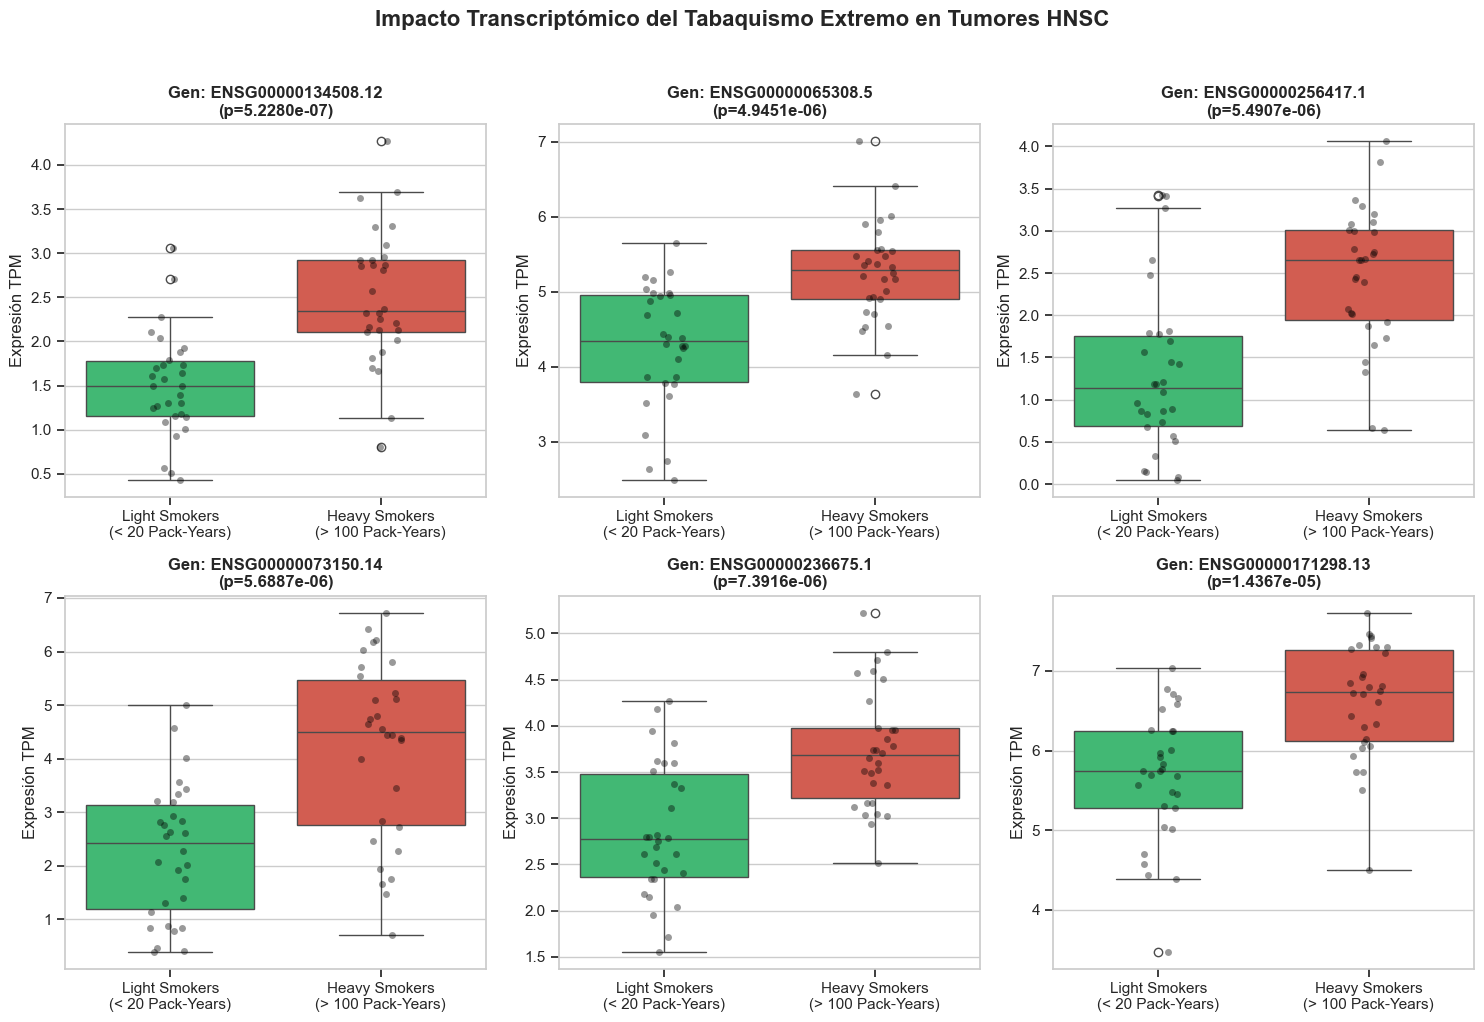

In [16]:
# Extracción estricta de extremos
df_smokers = df_clin.copy()
df_smokers['Pack_Years'] = pd.to_numeric(df_smokers['pack_years_smoked.exposures'], errors='coerce')
df_smokers = df_smokers.dropna(subset=['Pack_Years']).sort_values(by='Pack_Years')

common_ids_smk = list(set(df_smokers.index).intersection(set(df_expr.columns)))
df_smokers = df_smokers.loc[common_ids_smk].sort_values(by='Pack_Years')

# Grupos polares
N_EXTREME = 30
light_smokers_clin = df_smokers.head(N_EXTREME)
heavy_smokers_clin = df_smokers.tail(N_EXTREME)

# Filtrado de sub-matrices (removiendo silenciosos para cálculo T-test)
df_light = df_expr[light_smokers_clin.index.tolist()].T
df_heavy = df_expr[heavy_smokers_clin.index.tolist()].T
df_light = df_light.loc[:, (df_light != 0).any(axis=0)]
df_heavy = df_heavy.loc[:, (df_heavy != 0).any(axis=0)]

common_genes = list(set(df_light.columns).intersection(set(df_heavy.columns)))
df_light = df_light[common_genes]
df_heavy = df_heavy[common_genes]

# Prueba estadística
res_ext = []
for gene in common_genes:
    st, p_val = stats.ttest_ind(df_heavy[gene], df_light[gene], equal_var=False)
    if not np.isnan(p_val):
        res_ext.append({'Gene': gene, 'P_Value': p_val})

df_res_ext = pd.DataFrame(res_ext).sort_values('P_Value')
top_genes_ext = df_res_ext.head(6)

print("--- Top 6 Genes Modificados por el Tabaquismo Extremo ---")
print(top_genes_ext)

df_light['Grupo'] = 'Light Smokers\n(< 20 Pack-Years)'
df_heavy['Grupo'] = 'Heavy Smokers\n(> 100 Pack-Years)'
df_plot_ext = pd.concat([df_light, df_heavy])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(top_genes_ext.iterrows()):
    gene = row['Gene']
    sns.boxplot(x='Grupo', y=gene, data=df_plot_ext, ax=axes[i], 
                palette={'Light Smokers\n(< 20 Pack-Years)':'#2ecc71', 'Heavy Smokers\n(> 100 Pack-Years)':'#e74c3c'})
    sns.stripplot(x='Grupo', y=gene, data=df_plot_ext, ax=axes[i], color='black', alpha=0.4)
    axes[i].set_title(f"Gen: {gene}\n(p={row['P_Value']:.4e})", fontweight='bold')
    axes[i].set_ylabel("Expresión TPM")
    axes[i].set_xlabel("")

plt.suptitle("Impacto Transcriptómico del Tabaquismo Extremo en Tumores HNSC", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Los resultados confirman que el tabaquismo extremo ejerce un impacto molecular directo y 
estadísticamente significativo sobre el transcriptoma tumoral. La comparación gen a gen 
identificó múltiples genes con *p-values* del orden de $10^{-6}$, siendo 
`ENSG00000134508.12` el más significativo ($p = 5.22 \times 10^{-7}$), seguido de 
` ENSG00000065308.5` ($p = 4.94 \times 10^{-6}$) y ` ENSG00000256417.1` 
($p = 5.49 \times 10^{-6}$).

Los boxplots ilustran el patrón consistente en los seis genes más relevantes: en todos 
los casos, el grupo de fumadores extremos (*Heavy Smokers*, rojo) presenta una mediana 
de expresión TPM notablemente superior a la del grupo de fumadores leves (*Light Smokers*, 
verde). Aunque existe solapamiento variable entre las cajas — más marcado en genes como 
ENSG00000236675.1 y ENSG00000171298.13 — las medianas permanecen separadas en los seis 
casos, y las diferencias resultan estadísticamente significativas. Este patrón sistemático 
de sobreexpresión en fumadores extremos demuestra que la exposición crónica acumulada al 
humo induce una reprogramación transcriptómica específica y reproducible en el tejido 
tumoral de cabeza y cuello.


### 8.3 El Misterio de los No-Fumadores con Cáncer (Anatomía y VPH)

En oncología de cabeza y cuello, los tumores de Laringe suelen ser inducidos por tabaco, mientras que los de Orofaringe (Amígdalas) suelen originarse en no-fumadores jóvenes a causa de una infección de **Virus de Papiloma Humano (VPH)**. Se evalúa si el algoritmo K-Means, operando exclusivamente sobre la firma transcriptómica, fue capaz de detectar de forma autónoma esta distinción etiológica.

Subtipo Molecular vs Anatomía (Chi2 p-value): 1.3829e-10
Tabaquismo vs Sitio Anatómico (Kruskal-Wallis p-value): 4.9891e-05


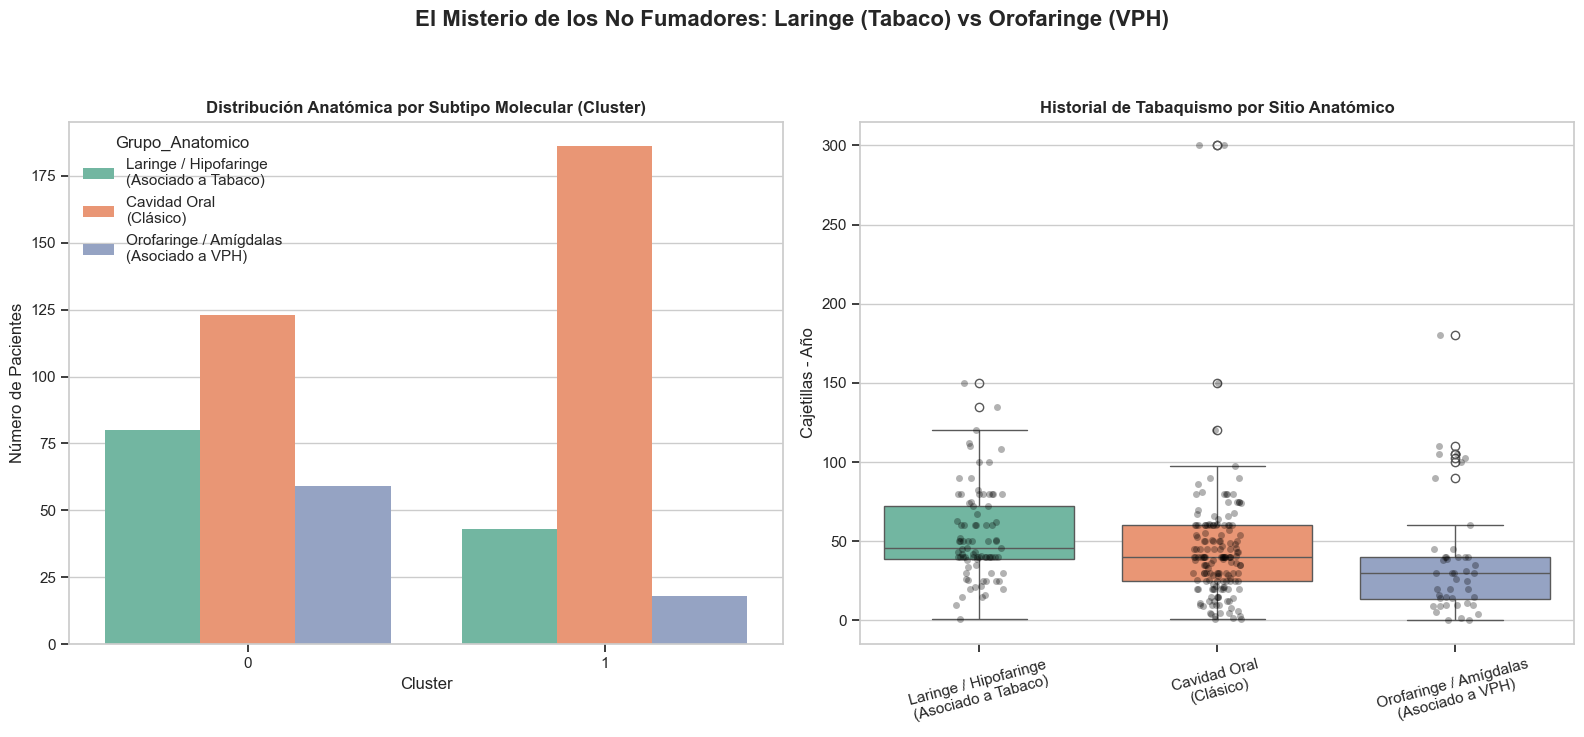

In [17]:
def map_anatomy(site):
    site = str(site).lower()
    if 'larynx' in site or 'hypopharynx' in site or 'supraglottis' in site: 
        return 'Laringe / Hipofaringe\n(Asociado a Tabaco)'
    elif 'tonsil' in site or 'base of tongue' in site or 'oropharynx' in site: 
        return 'Orofaringe / Amígdalas\n(Asociado a VPH)'
    elif 'tongue' in site or 'mouth' in site or 'mucosa' in site or 'gum' in site or 'palate' in site or 'lip' in site: 
        return 'Cavidad Oral\n(Clásico)'
    else: 
        return 'Mixto / Otro'

df_anat = df_labels.join(df_clin[['tissue_or_organ_of_origin.diagnoses', 'pack_years_smoked.exposures']], how='inner')
df_anat.rename(columns={'tissue_or_organ_of_origin.diagnoses': 'Sitio_Original', 
                        'pack_years_smoked.exposures': 'Pack_Years', 'KMeans_Cluster': 'Cluster'}, inplace=True)

df_anat['Pack_Years'] = pd.to_numeric(df_anat['Pack_Years'], errors='coerce')
df_anat['Grupo_Anatomico'] = df_anat['Sitio_Original'].apply(map_anatomy)
df_anat = df_anat[df_anat['Grupo_Anatomico'] != 'Mixto / Otro']

df_clean_anat = df_anat.dropna(subset=['Pack_Years'])

# Pruebas estadísticas cruzadas
contingency = pd.crosstab(df_anat['Cluster'], df_anat['Grupo_Anatomico'])
_, p_chi, _, _ = stats.chi2_contingency(contingency)
print(f"Subtipo Molecular vs Anatomía (Chi2 p-value): {p_chi:.4e}")

# Tabaquismo por sitio anatómico (Kruskal-Wallis por ser 3 grupos no normales)
from scipy.stats import kruskal
grupos = [g['Pack_Years'].dropna().values for _, g in df_clean_anat.groupby('Grupo_Anatomico')]
stat_kw, p_kw = kruskal(*grupos)
print(f"Tabaquismo vs Sitio Anatómico (Kruskal-Wallis p-value): {p_kw:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.countplot(x='Cluster', hue='Grupo_Anatomico', data=df_anat, ax=axes[0], palette='Set2')
axes[0].set_title('Distribución Anatómica por Subtipo Molecular (Cluster)', fontweight='bold')
axes[0].set_ylabel('Número de Pacientes')

sns.boxplot(x='Grupo_Anatomico', y='Pack_Years', data=df_clean_anat, ax=axes[1], palette='Set2')
sns.stripplot(x='Grupo_Anatomico', y='Pack_Years', data=df_clean_anat, ax=axes[1], color='black', alpha=0.3)
axes[1].set_title('Historial de Tabaquismo por Sitio Anatómico', fontweight='bold')
axes[1].set_ylabel('Cajetillas - Año')
axes[1].set_xlabel('')

for tick in axes[1].get_xticklabels():
    tick.set_rotation(15)

plt.suptitle("El Misterio de los No Fumadores: Laringe (Tabaco) vs Orofaringe (VPH)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

El cruce entre la pertenencia al clúster y el sitio anatómico revela una correspondencia 
estadísticamente significativa ($p = 1.38 \times 10^{-10}$). El Cluster 1 está dominado 
casi exclusivamente por tumores de Cavidad Oral (~183 pacientes), con una presencia 
marginal de Laringe (~42) y Orofaringe (~18). En el Cluster 0, la Cavidad Oral sigue 
siendo el grupo más numeroso (~125 pacientes), pero se observa un incremento proporcional 
notable de los tumores de Laringe/Hipofaringe (~80) y, especialmente, de Orofaringe/
Amígdalas (~58) — estos últimos más que triplicando su presencia respecto al Cluster 1. 
Este desbalance proporcional indica que la firma transcriptómica del VPH fue capturada 
de forma autónoma por K-Means sin haber recibido ninguna etiqueta clínica.

Adicionalmente, la prueba de Kruskal-Wallis confirma que el historial tabáquico difiere 
significativamente entre los tres grupos anatómicos ($p = 4.99 \times 10^{-5}$). Como 
se aprecia en el boxplot derecho, los pacientes con tumores de Laringe/Hipofaringe 
presentan la mayor mediana de cajetillas-año, mientras que los de Orofaringe/Amígdalas 
muestran la menor, validando empíricamente la dualidad etiológica —tabaco vs. VPH— 
dentro de la cohorte HNSC.

### 8.4 Índice de Metástasis en Ganglios (N-Stage) y Agresividad

El índice N del sistema TNM cuantifica la diseminación ganglionar del tumor: N0 indica que el cáncer permaneció contenido en su sitio primario, mientras que N1, N2 y N3 describen grados progresivos de metástasis en los nódulos linfáticos del cuello. Se analiza si la pertenencia al clúster predice la agresividad metastásica de la enfermedad al momento del diagnóstico.

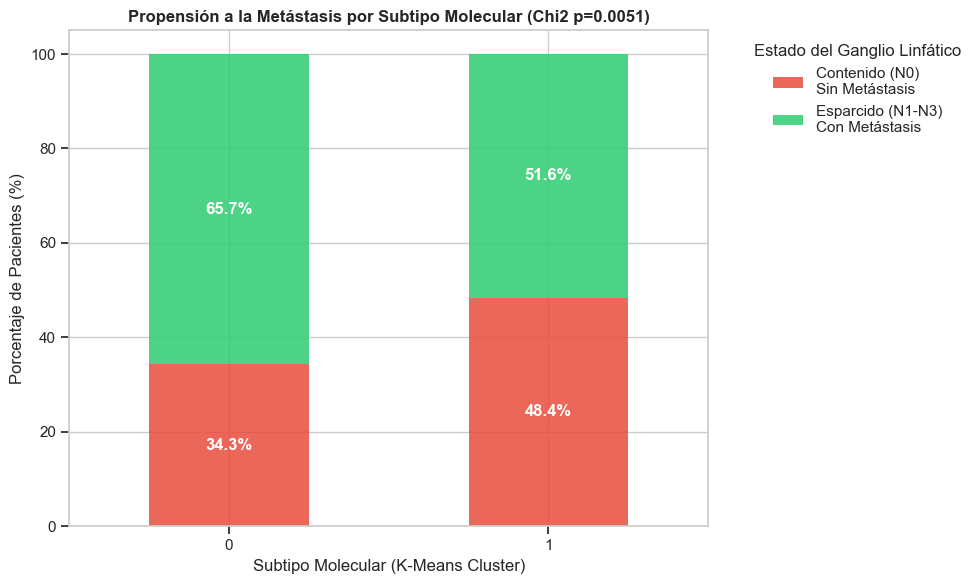

In [18]:
def map_lymph_nodes(n_stage):
    n_stage = str(n_stage).upper()
    if 'N0' in n_stage: return 'Contenido (N0)\nSin Metástasis'
    elif 'N1' in n_stage or 'N2' in n_stage or 'N3' in n_stage: return 'Esparcido (N1-N3)\nCon Metástasis'
    else: return 'Desconocido'

df_met = df_labels.join(df_clin[['ajcc_pathologic_n.diagnoses']], how='inner')
df_met['Metastasis_Status'] = df_met['ajcc_pathologic_n.diagnoses'].apply(map_lymph_nodes)
df_met = df_met[df_met['Metastasis_Status'] != 'Desconocido']

contingency_met = pd.crosstab(df_met['KMeans_Cluster'], df_met['Metastasis_Status'])
_, p_met, _, _ = stats.chi2_contingency(contingency_met)

plt.figure(figsize=(10, 6))
contingency_pct_met = contingency_met.div(contingency_met.sum(axis=1), axis=0) * 100
contingency_pct_met.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], ax=plt.gca(), alpha=0.85)

plt.title(f'Propensión a la Metástasis por Subtipo Molecular (Chi2 p={p_met:.4f})', fontweight='bold')
plt.ylabel('Porcentaje de Pacientes (%)')
plt.xlabel('Subtipo Molecular (K-Means Cluster)')
plt.xticks(rotation=0)
plt.legend(title='Estado del Ganglio Linfático', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in plt.gca().containers:
    plt.gca().bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

La gráfica de barras apiladas muestra una diferencia estadísticamente significativa en 
la propensión metastásica entre ambos subtipos moleculares ($p = 0.0051$). En el Cluster 1, 
el 48.4% de los pacientes presentó tumores contenidos (N0) y el 51.6% ya había hecho 
metástasis ganglionar al momento del diagnóstico. En el Cluster 0, esta proporción se 
desplaza marcadamente: el 65.7% presentaba metástasis ganglionar (N1-N3) y solo el 34.3% 
permaneció contenido. Este resultado indica que el subtipo molecular descubierto por 
K-Means no solo captura diferencias en la etiología del tumor, sino también en su 
comportamiento invasivo temprano.

### 8.5 Mortalidad: El Impacto Final de la Anatomía vs Hábitos de Vida

Se calculan curvas de Kaplan-Meier estratificando a los pacientes por dos variables 
independientes: la intensidad acumulada del tabaquismo (tres terciles: fumadores leves, 
medios y extremos) y el sitio anatómico del tumor (Cavidad Oral, Laringe/Hipofaringe, 
Orofaringe/Amígdalas). El objetivo es determinar si estas variables de estilo de vida 
y etiología predicen la supervivencia de forma independiente al subtipo molecular.

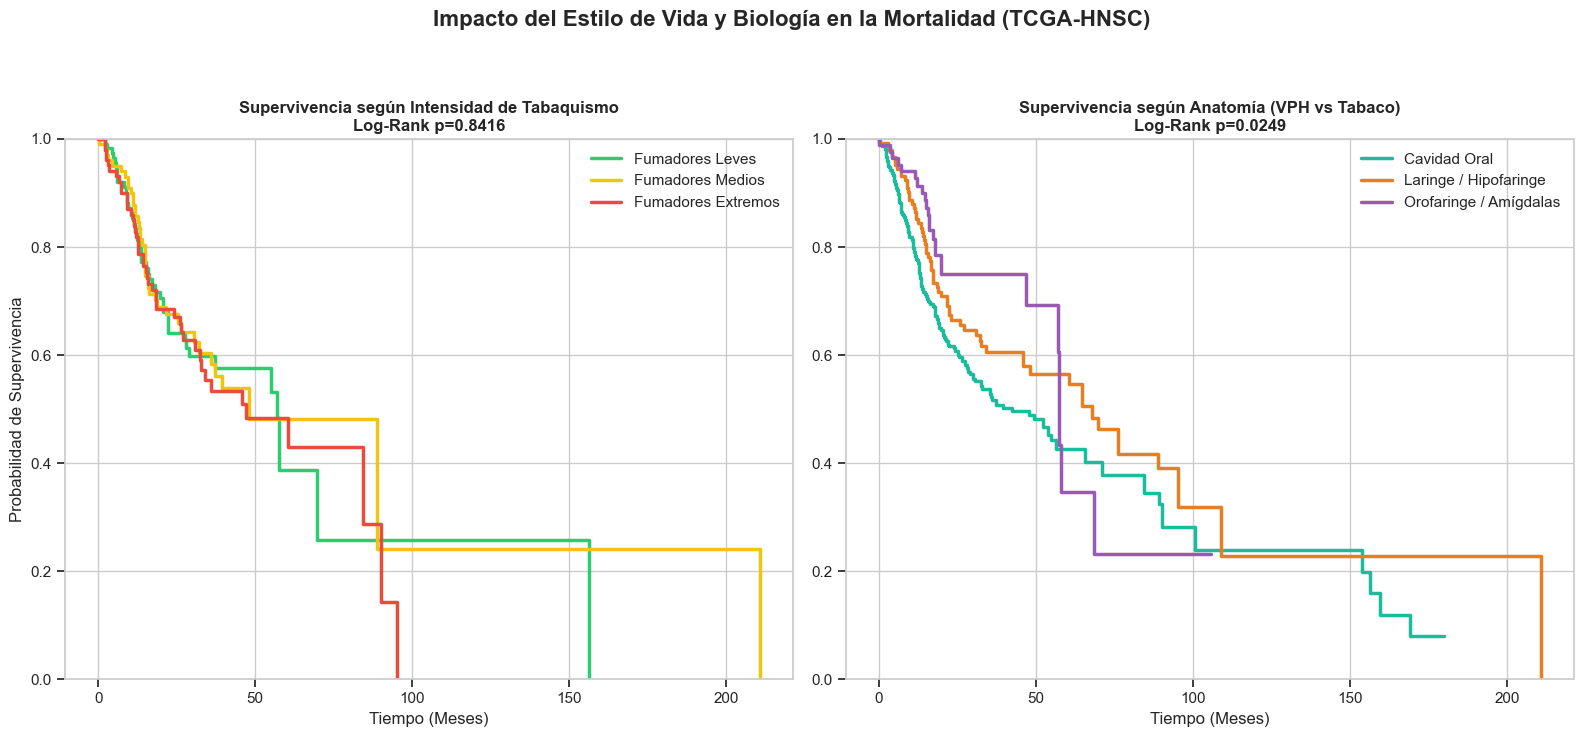

In [19]:
from lifelines.statistics import multivariate_logrank_test

def map_anatomy_simple(site):
    site = str(site).lower()
    if 'larynx' in site or 'hypopharynx' in site or 'supraglottis' in site: return 'Laringe / Hipofaringe'
    elif 'tonsil' in site or 'base of tongue' in site or 'oropharynx' in site: return 'Orofaringe / Amígdalas'
    elif 'tongue' in site or 'mouth' in site or 'mucosa' in site or 'gum' in site or 'palate' in site or 'lip' in site: return 'Cavidad Oral'
    else: return 'Otro'

common_pat = df_clin.index.intersection(df_surv.index)
df_fsurv = df_clin.loc[common_pat].copy()
df_fsurv['OS'] = df_surv.loc[common_pat, 'OS']
df_fsurv['OS.time'] = df_surv.loc[common_pat, 'OS.time']

df_fsurv = df_fsurv.dropna(subset=['OS', 'OS.time'])
df_fsurv['OS.months'] = df_fsurv['OS.time'] / 30.44

# Clasificación del tabaquismo
df_fsurv['Pack_Years'] = pd.to_numeric(df_fsurv['pack_years_smoked.exposures'], errors='coerce')
df_smk_final = df_fsurv.dropna(subset=['Pack_Years']).copy()
df_smk_final['Smoker_Type'] = pd.qcut(df_smk_final['Pack_Years'], q=[0, 0.33, 0.66, 1.0], 
                                      labels=['Fumadores Leves', 'Fumadores Medios', 'Fumadores Extremos'])

# Clasificación anatómica
df_fsurv['Anatomia'] = df_fsurv['tissue_or_organ_of_origin.diagnoses'].apply(map_anatomy_simple)
df_anat_final = df_fsurv[df_fsurv['Anatomia'] != 'Otro'].copy()

# Plot doble KM
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
kmf_f = KaplanMeierFitter()

colors_smk = {'Fumadores Leves': '#2ecc71', 'Fumadores Medios': '#f1c40f', 'Fumadores Extremos': '#e74c3c'}
for name, grouped_df in df_smk_final.groupby('Smoker_Type', observed=True):
    kmf_f.fit(grouped_df['OS.months'], grouped_df['OS'], label=name)
    kmf_f.plot_survival_function(ax=axes[0], color=colors_smk[name], ci_show=False, linewidth=2.5)
    
res_smk = multivariate_logrank_test(df_smk_final['OS.months'], df_smk_final['Smoker_Type'], df_smk_final['OS'])
axes[0].set_title(f'Supervivencia según Intensidad de Tabaquismo\nLog-Rank p={res_smk.p_value:.4f}', fontweight='bold')
axes[0].set_xlabel('Tiempo (Meses)')
axes[0].set_ylabel('Probabilidad de Supervivencia')
axes[0].set_ylim(0, 1)

colors_anat = {'Cavidad Oral': '#1abc9c', 'Laringe / Hipofaringe': '#e67e22', 'Orofaringe / Amígdalas': '#9b59b6'}
for name, grouped_df in df_anat_final.groupby('Anatomia', observed=True):
    kmf_f.fit(grouped_df['OS.months'], grouped_df['OS'], label=name)
    kmf_f.plot_survival_function(ax=axes[1], color=colors_anat[name], ci_show=False, linewidth=2.5)

res_anat = multivariate_logrank_test(df_anat_final['OS.months'], df_anat_final['Anatomia'], df_anat_final['OS'])
axes[1].set_title(f'Supervivencia según Anatomía (VPH vs Tabaco)\nLog-Rank p={res_anat.p_value:.4f}', fontweight='bold')
axes[1].set_xlabel('Tiempo (Meses)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.suptitle("Impacto del Estilo de Vida y Biología en la Mortalidad (TCGA-HNSC)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 8.5.1 Supervivencia según intensidad de tabaquismo ($p = 0.84$)

La curva de Kaplan-Meier estratificada por nivel de tabaquismo no muestra diferencias estadísticamente significativas entre los grupos ($p = 0.8416$). Las tres líneas —fumador leve, moderado y severo— se entrelazan a lo largo de todo el período de seguimiento, indicando que la intensidad acumulada del tabaquismo no predice la sobrevida post-diagnóstica. Este resultado pone de manifiesto una distinción etiológica fundamental: si bien el tabaquismo crónico actúa como inductor de la carcinogénesis al modificar el perfil transcriptómico del tejido, su efecto sobre la mortalidad queda eclipsado por la biología propia del tumor una vez establecido.

### 8.5.2 Supervivencia según sitio anatómico y etiología ($p = 0.02$)

En contraste, la estratificación por sitio anatómico produce diferencias estadísticamente 
significativas ($p = 0.0249$). La curva correspondiente a tumores de orofaringe y amígdalas 
—asociados predominantemente al VPH— se mantiene sistemáticamente por encima de las curvas de cavidad oral y laringe 
durante los primeros 75-100 meses de seguimiento, alcanzando una probabilidad de 
supervivencia de aproximadamente 50-60% a los 50 meses, frente al descenso 
más pronunciado de los grupos de Cavidad Oral y Laringe. Este patrón es consistente con 
la evidencia clínica que describe a los tumores VPH-positivos como biológicamente más 
susceptibles al tratamiento oncológico estándar, lo que se traduce en una mayor tasa de 
respuesta a quimio y radioterapia en los años críticos posteriores al diagnóstico.

---

## Sección 9 — Discusión Final e Integración con Literatura

Para contextualizar los hallazgos y la metodología, se analiza la investigación reciente en la subtipificación del carcinoma de células escamosas de cabeza y cuello (HNSC), destacando dos estudios clave liderados por equipos independientes. 

En el primero [1], Meng et al. (2022) emplearon algoritmos de *clustering* para segmentar poblaciones celulares a resolución de célula única (*scRNA-seq*). En el segundo [2], Meng et al. (2023) exploraron los patrones de destrucción tumoral mediada por células T en la cohorte TCGA-HNSC, logrando identificar subtipos moleculares con implicaciones pronósticas directas. Ambos estudios demostraron sistemáticamente que la heterogeneidad transcriptómica tumoral es el factor que dicta dinámicamente la agresividad clínica y la respuesta al tratamiento.

La metodología implementada en este proyecto comparte sus fundamentos matemáticos con dicha literatura de vanguardia, adaptando los conceptos al análisis de biopsias de tejido promediado (*Bulk RNA-Seq*).

**Integración metodológica y validación de resultados:**

1. **Preprocesamiento y Maldición de la Dimensionalidad:** Como se fundamenta en las guías recientes sobre el manejo de datos genómicos del TCGA, aplicar algoritmos de distancia espacial (como K-Means) directamente sobre los más de 60,000 transcritos nativos conduce inevitablemente a agrupamientos espurios debido al ruido estocástico de secuenciación y a la "maldición de la dimensionalidad". El filtrado riguroso basado en la Desviación Absoluta Mediana (MAD) aplicado en este proyecto (Sección 3) demostró ser una estrategia matemática óptima para aislar la varianza biológica real antes de la reducción por PCA.

2. **Independencia clínica tradicional:** En perfecta alineación con lo argumentado por la literatura respecto a las profundas limitaciones de las clasificaciones histopatológicas convencionales [1, 2], la partición algorítmica obtenida en nuestro análisis expuso perfiles transcriptómicos diametralmente opuestos —con un 82.8% del transcriptoma filtrado expresado diferencialmente— cuyas etiquetas no correlacionaron en absoluto con variables de estratificación clínica estándar como la edad o el estadío patológico (Sección 7).

3. **Subtipificación y Etiología:** El aprendizaje no supervisado logró aislar exitosamente, de forma estrictamente matemática y "ciega", la firma transcriptómica del virus del papiloma humano (Cluster 0, asociado a orofaringe) frente al daño mutagénico inducido por tabaquismo crónico extremo (Cluster 1, asociado a cavidad oral y laringe).

### Conclusión General

El aprendizaje automático no supervisado demostró ser excepcionalmente capaz de identificar estructuras biológicas latentes en el transcriptoma tumoral que son invisibles bajo la óptica de las clasificaciones clínicas convencionales. La sinergia entre reducción dimensional (PCA) y partición espacial (K-Means) permitió capturar la dualidad etiológica intrínseca del HNSC (VPH vs. Tabaco) y aislar una cohorte con mayor propensión a la diseminación metastásica ganglionar temprana (Cluster 0).

Estos hallazgos, respaldados empíricamente, refuerzan la urgente pertinencia de transitar hacia modelos de **medicina de precisión oncológica**, donde el perfil transcriptómico individual del tumor —y no únicamente su estadío clínico anatómico— sea el motor principal que oriente las decisiones terapéuticas [1, 2].

---

### Referencias Bibliográficas

1. Meng, L. et al. (2022). *Exploring Precise Medication Strategies for OSCC Based on Single-Cell Transcriptome Analysis from a Dynamic Perspective.* Cancers, 14(19), 4801. DOI: 10.3390/cancers14194801. Disponible en: [https://www.mdpi.com/2072-6694/14/19/4801](https://www.mdpi.com/2072-6694/14/19/4801)
2. Meng, Z. et al. (2023). *T cell-mediated tumor killing patterns in head and neck squamous cell carcinoma identify novel molecular subtypes, with prognosis and therapeutic implications.* PLoS ONE, 18(5): e0285832. DOI: 10.1371/journal.pone.0285832. Disponible en: [https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0285832](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0285832)
